# Prévision Budgétaire 2026 - Notebook Complet
## Analyse de séries temporelles : Prophet, SARIMA, ARIMA, Exponential Smoothing, Holt

In [23]:
# ═══════════════════════════════════════════════
# CELLULE 1 : Installation des dépendances
# ═══════════════════════════════════════════════

!pip install prophet pmdarima statsmodels scikit-learn matplotlib seaborn scipy -q

import prophet, statsmodels, pmdarima, sklearn
print(f"Prophet     : {prophet.__version__}")
print(f"Statsmodels : {statsmodels.__version__}")
print(f"pmdarima    : {pmdarima.__version__}")
print(f"sklearn     : {sklearn.__version__}")
print("✅ Installation OK")

Prophet     : 1.3.0
Statsmodels : 0.14.6
pmdarima    : 2.1.1
sklearn     : 1.6.1
✅ Installation OK


In [24]:
# ═══════════════════════════════════════════════
# CELLULE 2 : Imports
# ═══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, logging, io
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# ── Modèles ─────────────────────────────────────────────────────────
from prophet import Prophet
from pmdarima import auto_arima
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from scipy import stats

# ── Métriques ───────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ── Style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 25)

# ── Constantes ───────────────────────────────────────────────────────
TRAIN_SIZE  = 16   # 20 premiers mois
TEST_SIZE   = 8  # 4 derniers mois de 2025
HORIZON     = 12   # 12 mois à prévoir (2026)
ZERO_THRESH = 1e-6 # seuil pour détecter série nulle

print(f"✅ Config : Train={TRAIN_SIZE}pts | Test={TEST_SIZE}pts | Horizon={HORIZON}mois")

✅ Config : Train=16pts | Test=8pts | Horizon=12mois


In [25]:
# ═══════════════════════════════════════════════
# CELLULE 3 : Définition des agrégats cibles
# ═══════════════════════════════════════════════

"""
AGRÉGATS CIBLES :
Les 15 agrégats à modéliser, avec leur mapping vers les libellés
présents dans les fichiers CSV (sous-totaux/lignes de résumé).
"""

MOIS = ['Janvier','Fevrier','Mars','Avril','Mai','Juin',
        'Juillet','Aout','Septembre','Octobre','Novembre','Decembre']

AGGREGAT_MAPPING = {
    'CA Brut':                   ['CA Brut','CA BRUT'],
    'Retrocessions':             ['Retrocessions'],
    'Autres Produits Exploitation':["Autres Produits d'Exploitation",
                                    "Autres Produits d Exploitation"],
    'Frais Personnel':           ['Frais de Personnel'],
    'Honoraires Sous-traitance': ['Honoraires & Sous-traitance'],
    'Frais Commerciaux':         ['Frais Commerciaux'],
    'Impots Taxes':              ['Impôts et taxes','Impots et taxes'],
    'Fonctionnement Courant':    ['Fonctionnement Courant'],
    'Autres Charges':            ['Autres Charges'],
    'Produits Financiers':       ['Produits Financiers'],
    'Charges Financieres':       ['Charges Financières','Charges Financieres'],
    'Dotations Amortissements':  ['Dotations Amortissements & Provisions','Total D&A'],
    'Impot Societes':            ["Impôt sur les sociétés","Impot sur les societes"],
    'Produits Exceptionnels':    ['Produits Exceptionnels'],
    'Charges Exceptionnelles':   ['Charges Exceptionnelles'],
}

aggregats_list = list(AGGREGAT_MAPPING.keys())
print(f"✅ {len(aggregats_list)} agrégats définis")
for a in aggregats_list:
    print(f"   • {a}")

✅ 15 agrégats définis
   • CA Brut
   • Retrocessions
   • Autres Produits Exploitation
   • Frais Personnel
   • Honoraires Sous-traitance
   • Frais Commerciaux
   • Impots Taxes
   • Fonctionnement Courant
   • Autres Charges
   • Produits Financiers
   • Charges Financieres
   • Dotations Amortissements
   • Impot Societes
   • Produits Exceptionnels
   • Charges Exceptionnelles


In [26]:
# ═══════════════════════════════════════════════
# CELLULE 4 : Chargement des fichiers CSV
# ═══════════════════════════════════════════════

"""
UPLOAD DES 5 FICHIERS :
  1. budget_2024_cloture.csv
  2. budget_2025_cloture.csv
  3. budget_2025_Q1_3_9_nettoye.csv
  4. budget_2025_Q2_6_6_nettoye.csv
  5. budget_2025_Q3_8_4_nettoye.csv
"""

from google.colab import files as colab_files

print("📂 Upload vos 5 fichiers CSV...")
uploaded = colab_files.upload()

FILE_MAP = {
    '2024_cloture': 'budget_2024_cloture.csv',
    '2025_cloture': 'budget_2025_cloture.csv',
    '2025_Q1'     : 'budget_2025_Q1_3_9_nettoye.csv',
    '2025_Q2'     : 'budget_2025_Q2_6_6_nettoye.csv',
    '2025_Q3'     : 'budget_2025_Q3_8_4_nettoye.csv',
}

def load_csv(content):
    return pd.read_csv(io.StringIO(content), sep=';', header=0, dtype=str)

raw_dfs = {}
for key, fname in FILE_MAP.items():
    if fname in uploaded:
        raw_dfs[key] = load_csv(uploaded[fname].decode('utf-8'))
        print(f"  ✅ {fname} → {raw_dfs[key].shape}")
    else:
        print(f"  ⚠️  MANQUANT : {fname}")

print(f"\n📋 {len(raw_dfs)}/5 fichiers chargés.")

📂 Upload vos 5 fichiers CSV...


Saving budget_2024_cloture.csv to budget_2024_cloture.csv
Saving budget_2025_cloture.csv to budget_2025_cloture.csv
Saving budget_2025_Q1_3_9_nettoye.csv to budget_2025_Q1_3_9_nettoye.csv
Saving budget_2025_Q2_6_6_nettoye.csv to budget_2025_Q2_6_6_nettoye.csv
Saving budget_2025_Q3_8_4_nettoye.csv to budget_2025_Q3_8_4_nettoye.csv
  ✅ budget_2024_cloture.csv → (105, 17)
  ✅ budget_2025_cloture.csv → (105, 21)
  ✅ budget_2025_Q1_3_9_nettoye.csv → (105, 21)
  ✅ budget_2025_Q2_6_6_nettoye.csv → (105, 21)
  ✅ budget_2025_Q3_8_4_nettoye.csv → (105, 21)

📋 5/5 fichiers chargés.


In [27]:
# ═══════════════════════════════════════════════
# CELLULE 5 : Fonction d'extraction des agrégats
# ═══════════════════════════════════════════════

"""
EXTRACTION :
On cherche dans la colonne 'Libelle_SAGE' (3ème colonne) les lignes
correspondant aux sous-totaux de chaque agrégat (ex: 'CA Brut',
'Frais de Personnel', etc.) et on extrait les 12 valeurs mensuelles.
"""

def extract_aggregats(df, year, source_label=''):
    """
    Extrait les valeurs mensuelles pour chaque agrégat depuis le DataFrame brut.
    Retourne un DataFrame long : [aggregat, date, valeur, source]
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    col_libelle = df.columns[2]  # 'Libelle_SAGE'

    records = []
    for agg_name, libelles in AGGREGAT_MAPPING.items():
        found = False
        for libelle in libelles:
            mask = (df[col_libelle].fillna('')
                      .str.strip()
                      .str.lower()
                    == libelle.lower())
            rows = df[mask]
            if len(rows) == 0:
                continue

            row = rows.iloc[0]
            for i, mois in enumerate(MOIS):
                val = 0.0
                for col in df.columns:
                    if str(col).strip().lower() == mois.lower():
                        try:
                            raw = str(row[col]).strip()
                            val = 0.0 if raw in ['','nan','None','#VALUE!'] \
                                  else float(raw.replace(',','.'))
                        except:
                            val = 0.0
                        break
                records.append({
                    'aggregat': agg_name,
                    'date'    : pd.Timestamp(year=year, month=i+1, day=1),
                    'valeur'  : val,
                    'source'  : source_label
                })
            found = True
            break

        if not found:
            print(f"  ⚠️  '{agg_name}' non trouvé dans {source_label}")
            for i in range(12):
                records.append({
                    'aggregat': agg_name,
                    'date'    : pd.Timestamp(year=year, month=i+1, day=1),
                    'valeur'  : 0.0,
                    'source'  : source_label
                })

    return pd.DataFrame(records)

print("✅ Fonction d'extraction définie.")

✅ Fonction d'extraction définie.


In [28]:
# ═══════════════════════════════════════════════
# CELLULE 6 : Construction de la série principale (24 points)
# ═══════════════════════════════════════════════

"""
SÉRIE PRINCIPALE :
• 2024 (12 pts) : budget_2024_cloture  → budget réel 2024
• 2025 (12 pts) : budget_2025_cloture  → budget réel 2025

SPLIT :
  Train = points 1→20  (Jan-2024 → Août-2025)
  Test  = points 21→24 (Sep-2025 → Déc-2025)

Cette configuration donne 20 points d'entraînement et 4 de validation,
ce qui maximise l'information disponible pour l'apprentissage.
"""

df_2024 = extract_aggregats(raw_dfs['2024_cloture'], 2024, 'Cloture_2024')
df_2025 = extract_aggregats(raw_dfs['2025_cloture'], 2025, 'Cloture_2025')

df_main = (pd.concat([df_2024, df_2025], ignore_index=True)
             .sort_values(['aggregat','date'])
             .reset_index(drop=True))

# Nettoyage basique
df_main['valeur'] = (df_main['valeur']
                     .fillna(0)
                     .replace([np.inf, -np.inf], 0))

print(f"✅ Série principale : {df_main.shape[0]} lignes")
print(f"   Période : {df_main['date'].min()} → {df_main['date'].max()}")
print(f"   Agrégats : {df_main['aggregat'].nunique()}")

# Dates du split
all_dates  = sorted(df_main['date'].unique())
train_dates = all_dates[:TRAIN_SIZE]   # Jan-2024 → Août-2025
test_dates  = all_dates[TRAIN_SIZE:]   # Sep-2025 → Déc-2025
fc_dates    = pd.date_range('2026-01-01', periods=HORIZON, freq='MS')

print(f"\n   Split Train : {train_dates[0].date()} → {train_dates[-1].date()} ({len(train_dates)} pts)")
print(f"   Split Test  : {test_dates[0].date()}  → {test_dates[-1].date()}  ({len(test_dates)} pts)")
print(f"   Forecast    : {fc_dates[0].date()}  → {fc_dates[-1].date()}  ({len(fc_dates)} pts)")

✅ Série principale : 360 lignes
   Période : 2024-01-01 00:00:00 → 2025-12-01 00:00:00
   Agrégats : 15

   Split Train : 2024-01-01 → 2025-04-01 (16 pts)
   Split Test  : 2025-05-01  → 2025-12-01  (8 pts)
   Forecast    : 2026-01-01  → 2026-12-01  (12 pts)


In [29]:
# ═══════════════════════════════════════════════
# CELLULE 7 : Détection des séries nulles / constantes
# ═══════════════════════════════════════════════

"""
CLASSIFICATION DES AGRÉGATS :
Avant de modéliser, on classifie chaque agrégat :

  • NULLE       : toutes les valeurs == 0 → prévision = 0.0 directement
  • CONSTANTE   : std < seuil → prévision = moyenne constante
  • MODELISABLE : série avec vraie variabilité → appliquer les 5 modèles

Cette étape est cruciale pour éviter les prédictions NaN sur les séries
plates et garantir que la prévision de ces agrégats soit bien 0 (ou
la constante) et non NaN.
"""

serie_type = {}   # {agg: 'nulle' | 'constante' | 'modelisable'}
serie_stats = []

for agg in aggregats_list:
    vals = df_main[df_main['aggregat'] == agg]['valeur'].values

    all_zero  = np.all(np.abs(vals) < ZERO_THRESH)
    std_val   = np.std(vals)
    mean_val  = np.mean(vals)
    cv        = std_val / (abs(mean_val) + 1e-10)  # coefficient de variation

    if all_zero:
        stype = 'nulle'
    elif cv < 0.01 or std_val < 1.0:           # quasi-constante
        stype = 'constante'
    else:
        stype = 'modelisable'

    serie_type[agg] = stype
    serie_stats.append({
        'Agrégat'   : agg,
        'Type'      : stype,
        'Moyenne'   : round(mean_val, 2),
        'Std'       : round(std_val, 2),
        'CV'        : round(cv, 4),
        'Nb_Zeros'  : int(np.sum(np.abs(vals) < ZERO_THRESH))
    })

df_stats = pd.DataFrame(serie_stats)
print("📊 CLASSIFICATION DES AGRÉGATS")
print("=" * 75)
print(df_stats.to_string(index=False))

nulle_list       = [a for a,t in serie_type.items() if t == 'nulle']
constante_list   = [a for a,t in serie_type.items() if t == 'constante']
modelisable_list = [a for a,t in serie_type.items() if t == 'modelisable']

print(f"\n  🔴 Nulles        ({len(nulle_list)}) : {nulle_list}")
print(f"  🟡 Constantes    ({len(constante_list)}) : {constante_list}")
print(f"  🟢 Modélisables  ({len(modelisable_list)}) : {modelisable_list}")

📊 CLASSIFICATION DES AGRÉGATS
                     Agrégat        Type      Moyenne        Std   CV  Nb_Zeros
                     CA Brut modelisable 1,560,372.20 697,970.49 0.45         0
               Retrocessions       nulle         0.00       0.00 0.00        24
Autres Produits Exploitation modelisable     1,250.00   1,250.00 1.00        12
             Frais Personnel modelisable  -348,072.94  58,149.62 0.17         0
   Honoraires Sous-traitance modelisable  -425,438.54 190,226.49 0.45         0
           Frais Commerciaux modelisable   -91,834.24  40,334.43 0.44         0
                Impots Taxes modelisable    -9,661.71   4,354.53 0.45         0
      Fonctionnement Courant modelisable  -126,003.84  10,093.41 0.08         0
              Autres Charges modelisable   -23,086.19  39,017.82 1.69         0
         Produits Financiers       nulle         0.00       0.00 0.00        24
         Charges Financieres modelisable    -5,166.67   3,166.67 0.61         0
    Dotati

In [30]:
# ═══════════════════════════════════════════════
# CELLULE 8 : Prévisions directes (séries nulles et constantes)
# ═══════════════════════════════════════════════

"""
TRAITEMENT DIRECT DES SÉRIES NON-MODÉLISABLES :

• Séries NULLES     → prévision mensuelle = 0.0  (garantit pas de NaN)
• Séries CONSTANTES → prévision mensuelle = moyenne historique

Ces résultats sont stockés dans le même dictionnaire global que les
séries modélisables, assurant une cohérence du tableau final.
"""

# Dictionnaires globaux (remplis ici + cellule 14)
all_forecasts_2026 = {}   # {agg: Series(index=fc_dates)}
all_best_model     = {}   # {agg: str}
all_metrics_df     = {}   # {agg: DataFrame}
all_test_preds     = {}   # {agg: dict}

mois_labels = [d.strftime('%b-%y') for d in fc_dates]

for agg in nulle_list:
    fc = pd.Series(np.zeros(HORIZON), index=fc_dates)
    all_forecasts_2026[agg] = fc
    all_best_model[agg]     = 'Zéro (série nulle)'
    print(f"  🔴 {agg:35s} → 0.0 (série nulle)")

for agg in constante_list:
    vals    = df_main[df_main['aggregat'] == agg]['valeur'].values
    mean_v  = np.mean(vals)
    fc      = pd.Series(np.full(HORIZON, mean_v), index=fc_dates)
    all_forecasts_2026[agg] = fc
    all_best_model[agg]     = f'Constante (moy={mean_v:,.0f})'
    print(f"  🟡 {agg:35s} → {mean_v:,.2f} (constante)")

print(f"\n✅ {len(nulle_list)+len(constante_list)} agrégats traités directement.")

  🔴 Retrocessions                       → 0.0 (série nulle)
  🔴 Produits Financiers                 → 0.0 (série nulle)
  🔴 Produits Exceptionnels              → 0.0 (série nulle)
  🔴 Charges Exceptionnelles             → 0.0 (série nulle)

✅ 4 agrégats traités directement.


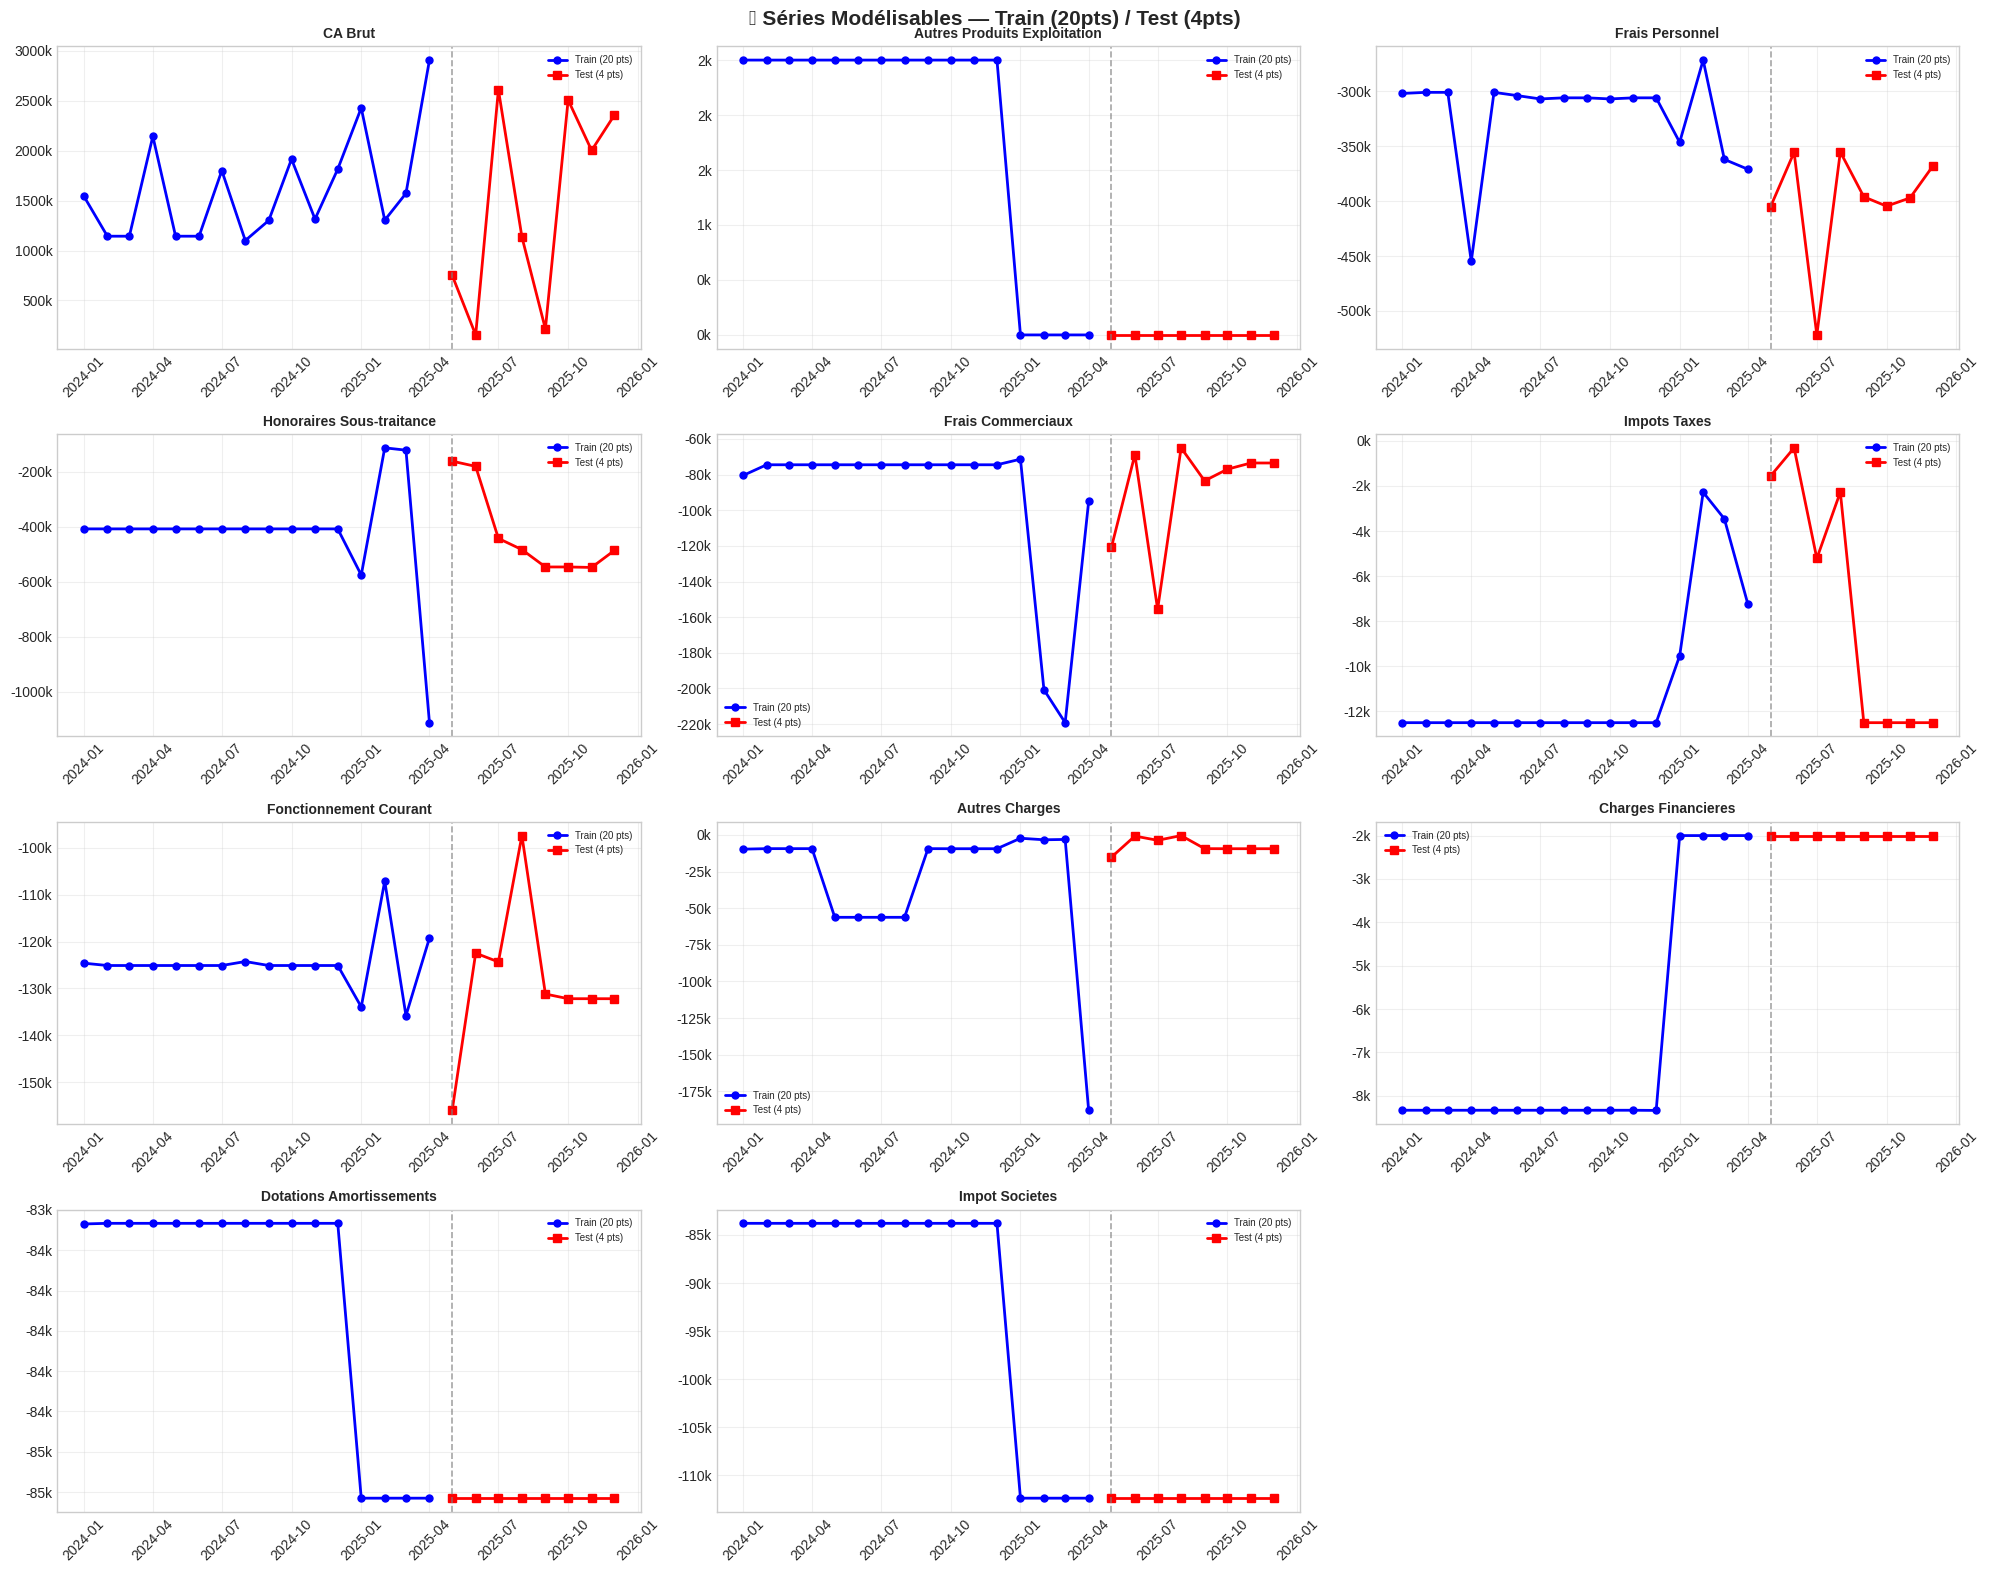

✅ EDA des séries modélisables affichée.


In [31]:
# ═══════════════════════════════════════════════
# CELLULE 9 : Analyse EDA des séries modélisables
# ═══════════════════════════════════════════════

"""
EDA CIBLÉE SUR LES SÉRIES MODÉLISABLES :
  1. Graphiques des séries brutes (train / test)
  2. Décomposition STL pour les séries avec ≥ 12 points
  3. Profil saisonnier mensuel
"""

n_mod = len(modelisable_list)
ncols = 3
nrows = (n_mod + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*4))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

for i, agg in enumerate(modelisable_list):
    ax = axes[i]
    subset = df_main[df_main['aggregat'] == agg].sort_values('date')

    train_vals = subset[subset['date'].isin(train_dates)]
    test_vals  = subset[subset['date'].isin(test_dates)]

    ax.plot(train_vals['date'], train_vals['valeur'],
            'b-o', lw=2, ms=5, label='Train (20 pts)')
    ax.plot(test_vals['date'],  test_vals['valeur'],
            'r-s', lw=2, ms=6, label='Test (4 pts)')

    # Ligne de séparation train/test
    ax.axvline(x=test_dates[0], color='gray', ls='--', lw=1.2, alpha=0.7)

    ax.set_title(f'{agg}', fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1000:.0f}k'))
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 Séries Modélisables — Train (20pts) / Test (4pts)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_series_modelisables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA des séries modélisables affichée.")

In [32]:
# ═══════════════════════════════════════════════
# CELLULE 10 : Tests de stationnarité et détection saisonnalité
# ═══════════════════════════════════════════════

"""
TESTS STATISTIQUES SUR LE TRAIN SET (20 pts) :
  • ADF   : H0 = non-stationnaire → p < 0.05 ⟹ stationnaire
  • KPSS  : H0 = stationnaire      → p > 0.05 ⟹ stationnaire
  • CV saisonnier : coefficient de variation des moyennes par mois
    > 0.15 ⟹ saisonnalité détectée
"""

def test_stationnarite(series, name=""):
    series = series.dropna()
    adf  = adfuller(series, autolag='AIC')
    try:
        kpss_r = kpss(series, regression='c', nlags='auto')
        kpss_p = round(kpss_r[1], 4)
    except:
        kpss_p = np.nan
    return {
        'Agrégat'      : name,
        'ADF_pval'     : round(adf[1], 4),
        'ADF_Stat'     : bool(adf[1] < 0.05),
        'KPSS_pval'    : kpss_p,
        'KPSS_Stat'    : bool(kpss_p > 0.05) if not np.isnan(kpss_p) else None,
    }

def detect_saisonnalite(series, name=""):
    df_t = pd.DataFrame({'mois': series.index.month, 'val': series.values})
    mm   = df_t.groupby('mois')['val'].mean()
    cv   = mm.std() / (abs(mm.mean()) + 1e-10)
    return {
        'Agrégat'     : name,
        'CV_saison'   : round(cv, 4),
        'has_season'  : bool(cv > 0.15),
    }

stat_res  = []
saison_res = []

for agg in modelisable_list:
    train_s = (df_main[df_main['aggregat'] == agg]
               .sort_values('date')
               .set_index('date')['valeur']
               .loc[train_dates])
    stat_res.append(test_stationnarite(train_s, agg))
    saison_res.append(detect_saisonnalite(train_s, agg))

df_statio  = pd.DataFrame(stat_res)
df_saison  = pd.DataFrame(saison_res)

print("🔬 STATIONNARITÉ :")
print(df_statio.to_string(index=False))
print("\n📅 SAISONNALITÉ :")
print(df_saison.to_string(index=False))

# Dictionnaire de décision
decision_saison = dict(zip(df_saison['Agrégat'], df_saison['has_season']))
print("\n✅ Décisions saisonnalité :", decision_saison)

🔬 STATIONNARITÉ :
                     Agrégat  ADF_pval  ADF_Stat  KPSS_pval  KPSS_Stat
                     CA Brut      0.99     False       0.06       True
Autres Produits Exploitation      0.89     False       0.06       True
             Frais Personnel      0.16     False       0.10       True
   Honoraires Sous-traitance      0.00      True       0.10       True
           Frais Commerciaux      0.90     False       0.09       True
                Impots Taxes      1.00     False       0.08       True
      Fonctionnement Courant      0.00      True       0.10       True
              Autres Charges      0.00      True       0.10       True
         Charges Financieres      0.00      True       0.06       True
    Dotations Amortissements      0.89     False       0.06       True
              Impot Societes      0.89     False       0.06       True

📅 SAISONNALITÉ :
                     Agrégat  CV_saison  has_season
                     CA Brut       0.29        True
Autres P

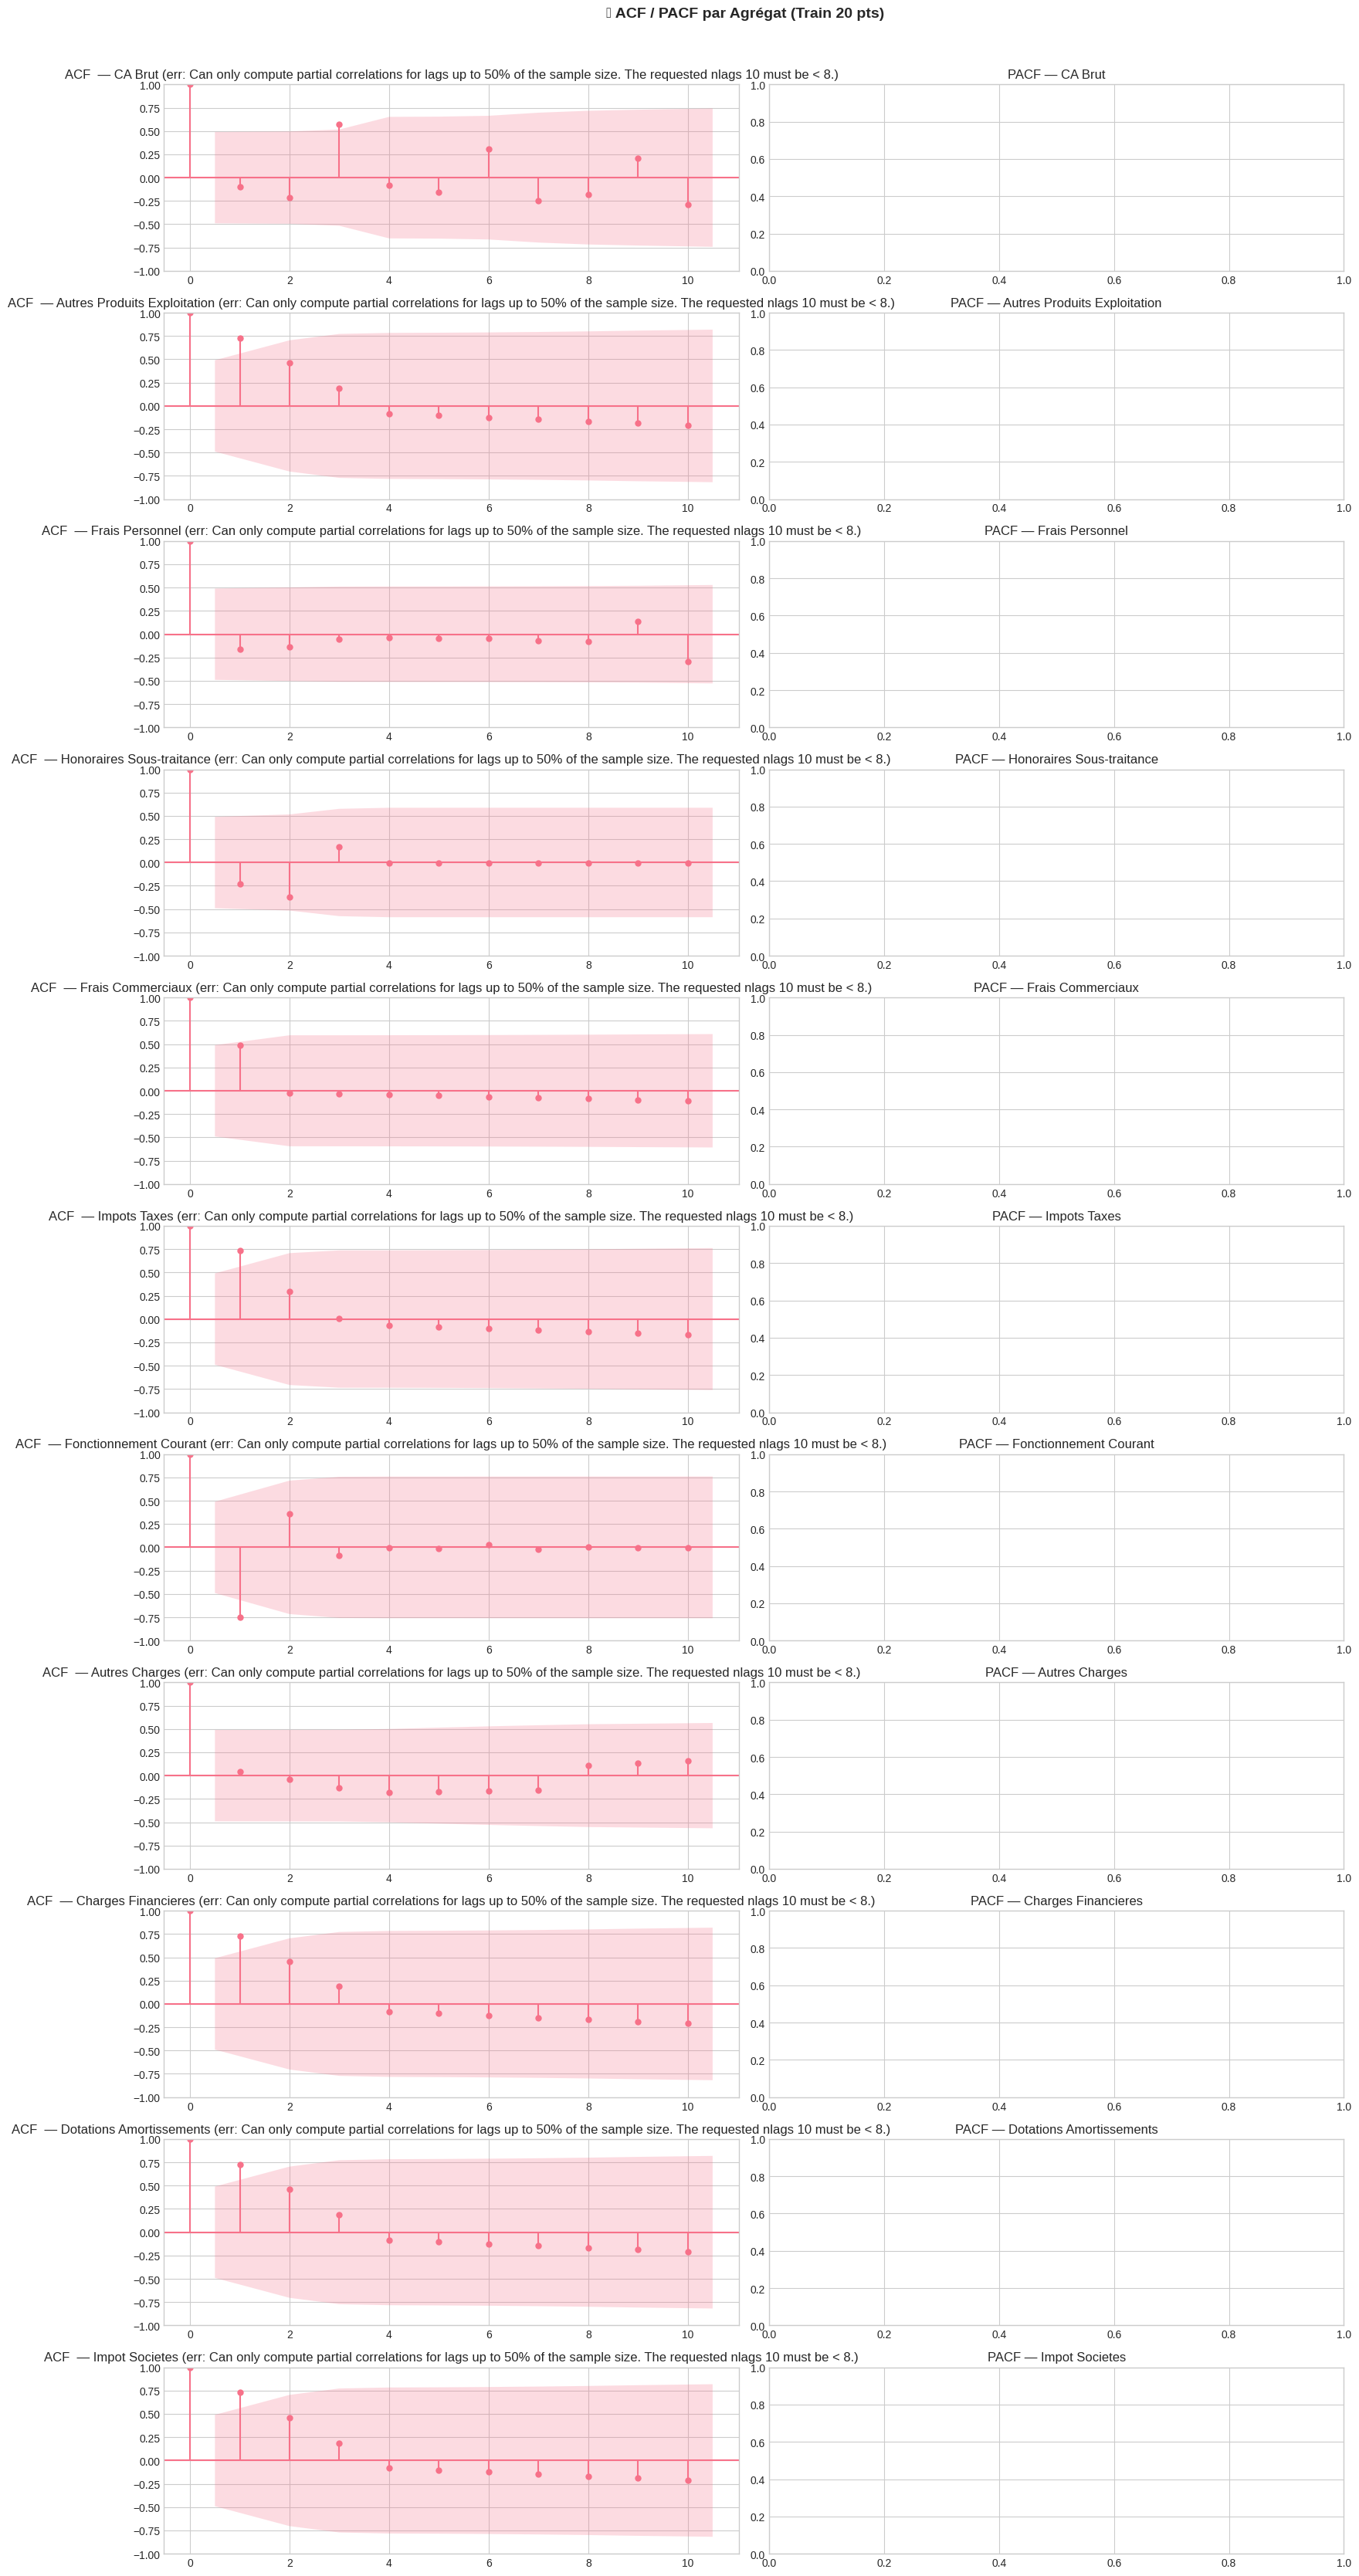

✅ ACF/PACF générés.


In [33]:
# ═══════════════════════════════════════════════
# CELLULE 11 : ACF / PACF
# ═══════════════════════════════════════════════

"""
ACF / PACF SUR LE TRAIN SET :
Permettent de choisir les ordres p, q pour ARIMA :
  • PACF coupe après lag p  → ordre AR = p
  • ACF  coupe après lag q  → ordre MA = q
  • Pics aux multiples de 12 → saisonnalité annuelle
"""

n = len(modelisable_list)
fig, axes = plt.subplots(n, 2, figsize=(16, n * 3))
if n == 1:
    axes = [axes]

for i, agg in enumerate(modelisable_list):
    train_s = (df_main[df_main['aggregat'] == agg]
               .sort_values('date')
               .set_index('date')['valeur']
               .loc[train_dates])

    max_lags = min(10, len(train_s) - 2)
    try:
        plot_acf( train_s, lags=max_lags, ax=axes[i][0],
                  title=f'ACF  — {agg}',  alpha=0.05)
        plot_pacf(train_s, lags=max_lags, ax=axes[i][1],
                  title=f'PACF — {agg}', alpha=0.05)
    except Exception as e:
        axes[i][0].set_title(f'ACF  — {agg} (err: {e})')
        axes[i][1].set_title(f'PACF — {agg}')

plt.suptitle('📈 ACF / PACF par Agrégat (Train 20 pts)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ACF/PACF générés.")

In [34]:
# ═══════════════════════════════════════════════
# CELLULE 12 : Métriques et classement
# ═══════════════════════════════════════════════

"""
MÉTRIQUES D'ÉVALUATION :
  • MAE   : erreur absolue moyenne
  • RMSE  : racine de l'erreur quadratique (pénalise les grosses erreurs)
  • MAPE  : erreur % (éviter si dénominateur ≈ 0)
  • sMAPE : MAPE symétrique (moins sensible aux zéros)
  • R²    : proportion de variance expliquée (cible : R² ≥ 0.85)

CLASSEMENT :
  Score combiné = rang(RMSE) + rang(MAE) + rang(sMAPE)
  → plus faible = meilleur modèle
"""

def compute_metrics(y_true, y_pred, model_name=""):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE robuste (ignore les y_true = 0)
    nz = np.abs(y_true) > 1e-10
    if nz.sum() > 0:
        mape = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) * 100
    else:
        mape = np.nan

    return {
        'Modèle': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE(%)': round(mape, 2) if not np.isnan(mape) else 999.0
    }

def rank_models(metrics_list, w_rmse=0.4, w_mae=0.3, w_mape=0.3):
    """
    Classement multi-critères basé UNIQUEMENT sur MAE, RMSE, MAPE.
    Plus le score est faible, meilleur est le modèle.
    """
    df = pd.DataFrame(metrics_list).copy()

    # rangs (plus petit = meilleur)
    df['rk_RMSE'] = df['RMSE'].rank(ascending=True, method='average')
    df['rk_MAE']  = df['MAE'].rank(ascending=True, method='average')
    df['rk_MAPE'] = df['MAPE(%)'].rank(ascending=True, method='average')

    # score pondéré
    df['Score'] = (
        w_rmse * df['rk_RMSE'] +
        w_mae  * df['rk_MAE']  +
        w_mape * df['rk_MAPE']
    )

    df = df.sort_values(['Score', 'RMSE', 'MAE', 'MAPE(%)']).reset_index(drop=True)
    df['Rang'] = np.arange(1, len(df) + 1)

    return df[['Modèle', 'MAE', 'RMSE', 'MAPE(%)', 'Score', 'Rang']]
print("✅ Fonctions métriques et classement définies.")

✅ Fonctions métriques et classement définies.


In [38]:
# ═══════════════════════════════════════════════
# CELLULE 12 : Métriques et classement
# ═══════════════════════════════════════════════

"""
MÉTRIQUES D'ÉVALUATION :
  • MAE   : erreur absolue moyenne
  • RMSE  : racine de l'erreur quadratique (pénalise les grosses erreurs)
  • MAPE  : erreur % (éviter si dénominateur ≈ 0)
  • sMAPE : MAPE symétrique (moins sensible aux zéros)

CLASSEMENT :
  Score combiné = rang(RMSE) + rang(MAE) + rang(sMAPE)
  → plus faible = meilleur modèle
"""

def compute_metrics(y_true, y_pred, model_name=""):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE robuste (ignore les y_true = 0)
    nz = np.abs(y_true) > 1e-10
    if nz.sum() > 0:
        mape = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) * 100
    else:
        mape = np.nan

    return {
        'Modèle': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE(%)': round(mape, 2) if not np.isnan(mape) else 999.0
    }

def rank_models(metrics_list, w_rmse=0.4, w_mae=0.3, w_mape=0.3):
    """
    Classement multi-critères basé sur MAE, RMSE, MAPE.
    Plus le score est faible, meilleur est le modèle.
    """
    df = pd.DataFrame(metrics_list).copy()

    # rangs (plus petit = meilleur pour error metrics)
    df['rk_RMSE'] = df['RMSE'].rank(ascending=True, method='average')
    df['rk_MAE']  = df['MAE'].rank(ascending=True, method='average')
    df['rk_MAPE'] = df['MAPE(%)'].rank(ascending=True, method='average')

    # score pondéré
    df['Score'] = (
        w_rmse * df['rk_RMSE'] +
        w_mae  * df['rk_MAE']  +
        w_mape * df['rk_MAPE']
    )

    df = df.sort_values(['Score', 'RMSE', 'MAE', 'MAPE(%)'], ascending=[True, True, True, True]).reset_index(drop=True)
    df['Rang'] = np.arange(1, len(df) + 1)

    return df[['Modèle', 'MAE', 'RMSE', 'MAPE(%)', 'Score', 'Rang']]
print("✅ Fonctions métriques et classement définies.")

✅ Fonctions métriques et classement définies.


In [36]:
# ═══════════════════════════════════════════════
# CELLULE 14 : Boucle principale de modélisation
# ═══════════════════════════════════════════════

"""
BOUCLE PRINCIPALE :
Pour chaque agrégat MODÉLISABLE :
  1. Extraire train (20 pts) et test (4 pts)
  2. Entraîner les 5 modèles optimisés
  3. Calculer les métriques sur le test
  4. Classer les modèles (score combiné incluant R²)
  5. Générer la prévision 2026 avec LE MEILLEUR modèle
  6. Stocker tous les résultats

Durée estimée : 10-25 min selon la complexité des séries.
"""

print("🚀 DÉMARRAGE MODÉLISATION (séries modélisables)")
print("=" * 70)

for agg in modelisable_list:
    print(f"\n{'─'*60}")
    print(f"📈  {agg}")
    print(f"{'─'*60}")

    # ── Extraction train / test ───────────────────────────────────
    subset = df_main[df_main['aggregat'] == agg].sort_values('date').set_index('date')

    train_s = subset.loc[train_dates, 'valeur']
    test_s  = subset.loc[test_dates,  'valeur']
    train_s.index.freq = 'MS'
    test_s.index.freq  = 'MS'

    has_season = decision_saison.get(agg, False)
    print(f"   Saisonnalité : {'✅ Oui' if has_season else '❌ Non'}")
    print(f"   Train : {train_s.index[0].date()} → {train_s.index[-1].date()}")
    print(f"   Test  : {test_s.index[0].date()}  → {test_s.index[-1].date()}")

    metrics_agg  = []
    preds_test   = {}
    forecasts_fc = {}

    # ── 1. PROPHET ──────────────────────────────────────────────────
    print("   [1/5] Prophet...")
    try:
        pt, pfc, params = fit_prophet_optimized(train_s, test_s, has_season, HORIZON)
        m = compute_metrics(test_s.values, pt, 'Prophet')
        metrics_agg.append(m)
        preds_test['Prophet']   = pt
        forecasts_fc['Prophet'] = pfc
        print(f"        RMSE={m['RMSE']:,.0f} | MAE={m['MAE']:,.0f} | MAPE={m['MAPE(%)']:.2f}%")
    except Exception as e:
        print(f"        ❌ {e}")

    # ── 2. SARIMA ───────────────────────────────────────────────────
    print("   [2/5] SARIMA...")
    try:
        pt, pfc, order = fit_sarima_optimized(train_s, test_s, has_season, HORIZON)
        m = compute_metrics(test_s.values, pt, 'SARIMA')
        metrics_agg.append(m)
        preds_test['SARIMA']   = pt
        forecasts_fc['SARIMA'] = pfc
        print(f"        RMSE={m['RMSE']:,.0f} | MAE={m['MAE']:,.0f} | MAPE={m['MAPE(%)']:.2f}%")
    except Exception as e:
        print(f"        ❌ {e}")

    # ── 3. ARIMA ────────────────────────────────────────────────────
    print("   [3/5] ARIMA (+ Box-Cox)...")
    try:
        pt, pfc, order = fit_arima_optimized(train_s, test_s, HORIZON)
        m = compute_metrics(test_s.values, pt, 'ARIMA')
        metrics_agg.append(m)
        preds_test['ARIMA']   = pt
        forecasts_fc['ARIMA'] = pfc
        print(f"        RMSE={m['RMSE']:,.0f} | MAE={m['MAE']:,.0f} | MAPE={m['MAPE(%)']:.2f}%")
    except Exception as e:
        print(f"        ❌ {e}")

    # ── 4. EXP SMOOTHING ────────────────────────────────────────────
    print("   [4/5] Exponential Smoothing...")
    try:
        pt, pfc, info = fit_ets_optimized(train_s, test_s, has_season, HORIZON)
        m = compute_metrics(test_s.values, pt, 'ExpSmoothing')
        metrics_agg.append(m)
        preds_test['ExpSmoothing']   = pt
        forecasts_fc['ExpSmoothing'] = pfc
        print(f"        RMSE={m['RMSE']:,.0f} | MAE={m['MAE']:,.0f} | MAPE={m['MAPE(%)']:.2f}%")
    except Exception as e:
        print(f"        ❌ {e}")

    # ── 5. HOLT ─────────────────────────────────────────────────────
    print("   [5/5] Holt...")
    try:
        pt, pfc, variant = fit_holt_optimized(train_s, test_s, HORIZON)
        m = compute_metrics(test_s.values, pt, 'Holt')
        metrics_agg.append(m)
        preds_test['Holt']   = pt
        forecasts_fc['Holt'] = pfc
        print(f"        RMSE={m['RMSE']:,.0f} | MAE={m['MAE']:,.0f} | MAPE={m['MAPE(%)']:.2f}%")
    except Exception as e:
        print(f"        ❌ {e}")

    # ── Classement ───────────────────────────────────────────────────
    if not metrics_agg:
        print(f"   ⚠️  Aucun modèle n'a convergé pour {agg}")
        avg = pd.concat([train_s, test_s]).mean()
        all_forecasts_2026[agg] = pd.Series(np.full(HORIZON, avg), index=fc_dates)
        all_best_model[agg]     = 'Moyenne (fallback)'
        continue

    df_rank = rank_models(metrics_agg)
    best    = df_rank.iloc[0]['Modèle']

    all_metrics_df[agg] = df_rank
    all_test_preds[agg] = {'test_s': test_s, 'preds': preds_test, 'train_s': train_s}

    # Prévision 2026 = prédiction du meilleur modèle
    fc_vals = forecasts_fc.get(best, np.full(HORIZON, pd.concat([train_s, test_s]).mean()))
    all_forecasts_2026[agg] = pd.Series(fc_vals[:HORIZON], index=fc_dates)
    all_best_model[agg]     = best

    print(f"\n   🏆 MEILLEUR : {best}")
    print(df_rank[['Modèle','RMSE','MAE','MAPE(%)','Score','Rang']].to_string(index=False))
print("\n" + "="*70)
print("✅ MODÉLISATION TERMINÉE")
print(f"   Agrégats modélisés : {len(all_metrics_df)}")
print(f"   Agrégats nuls/cst  : {len(nulle_list)+len(constante_list)}")

🚀 DÉMARRAGE MODÉLISATION (séries modélisables)

────────────────────────────────────────────────────────────
📈  CA Brut
────────────────────────────────────────────────────────────
   Saisonnalité : ✅ Oui
   Train : 2024-01-01 → 2025-04-01
   Test  : 2025-05-01  → 2025-12-01
   [1/5] Prophet...
        RMSE=605,648 | MAE=512,936 | MAPE=133.26%
   [2/5] SARIMA...
        RMSE=964,400 | MAE=901,865 | MAPE=226.01%
   [3/5] ARIMA (+ Box-Cox)...
        RMSE=1,045,470 | MAE=860,945 | MAPE=258.15%
   [4/5] Exponential Smoothing...
        RMSE=970,089 | MAE=901,865 | MAPE=232.81%
   [5/5] Holt...
        RMSE=1,102,719 | MAE=890,199 | MAPE=293.38%

   🏆 MEILLEUR : Prophet
      Modèle         RMSE        MAE  MAPE(%)  Score  Rang
     Prophet   605,648.32 512,936.07   133.26   1.00     1
      SARIMA   964,399.99 901,864.56   226.01   2.75     2
       ARIMA 1,045,470.34 860,944.92   258.15   3.40     3
ExpSmoothing   970,088.89 901,864.56   232.81   3.45     4
        Holt 1,102,719.31 890,

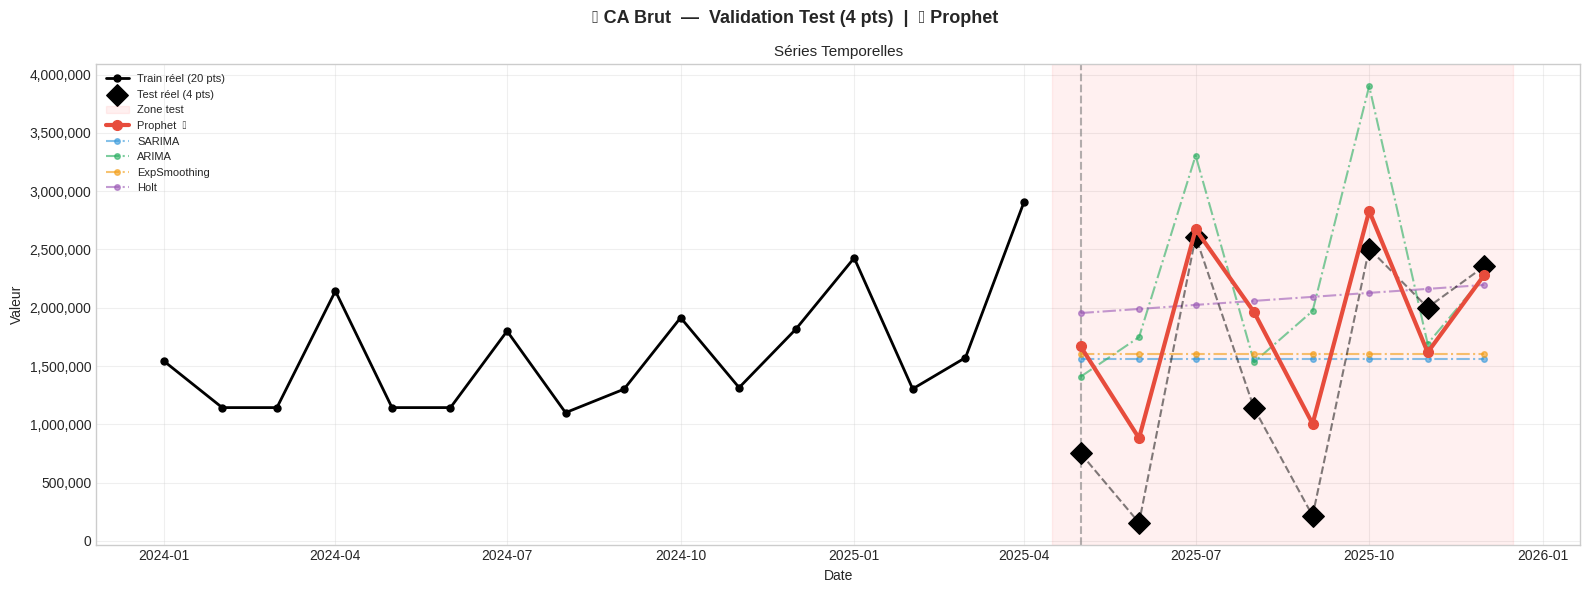

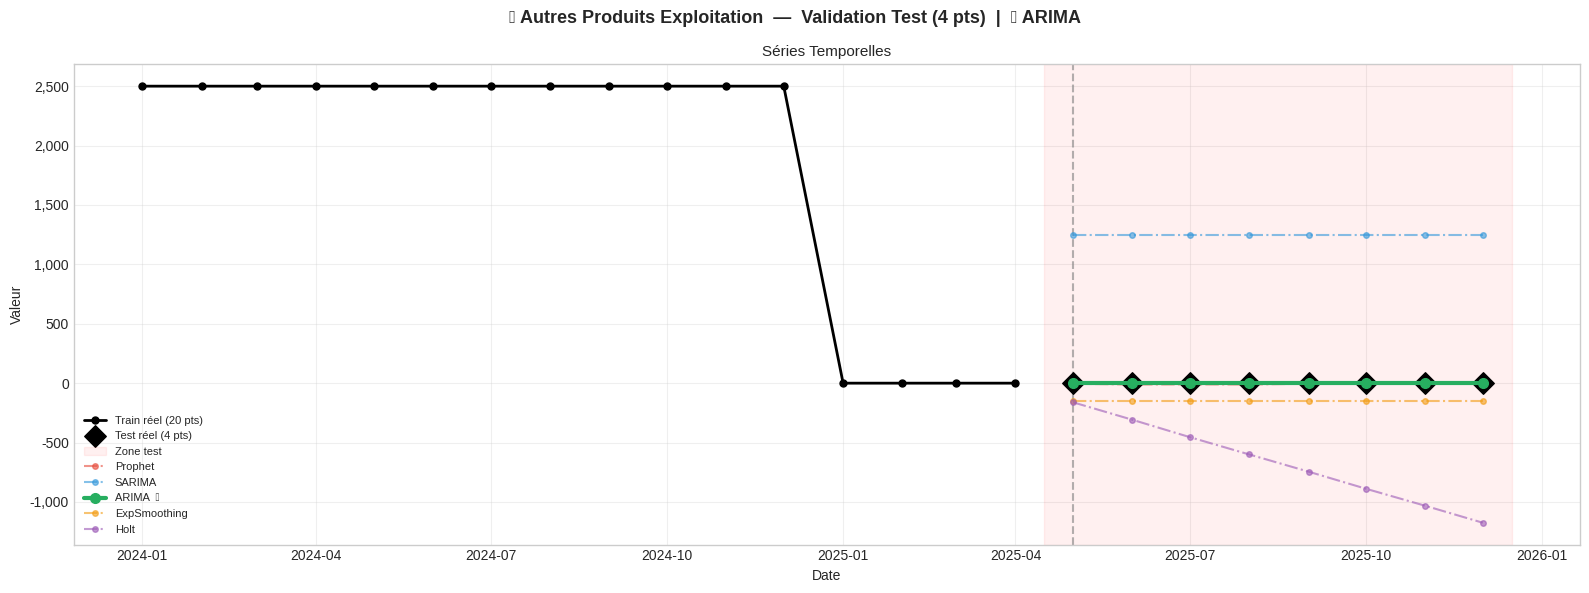

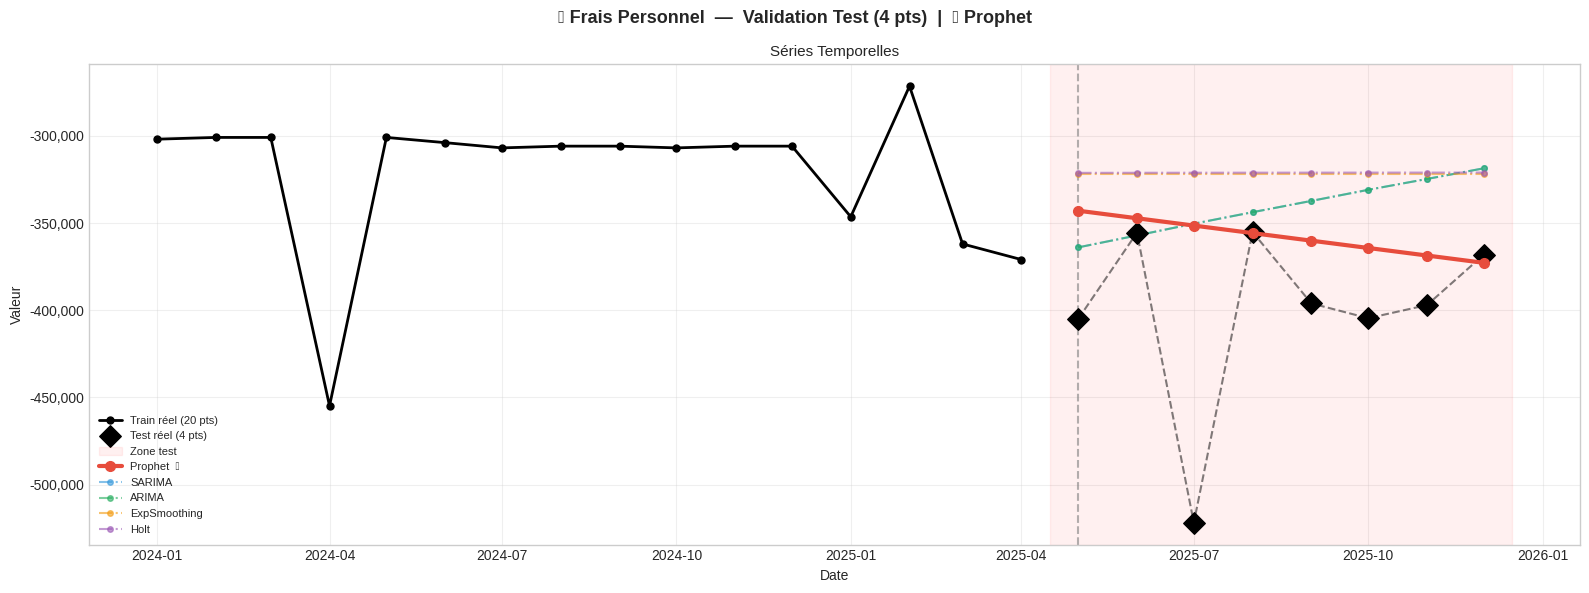

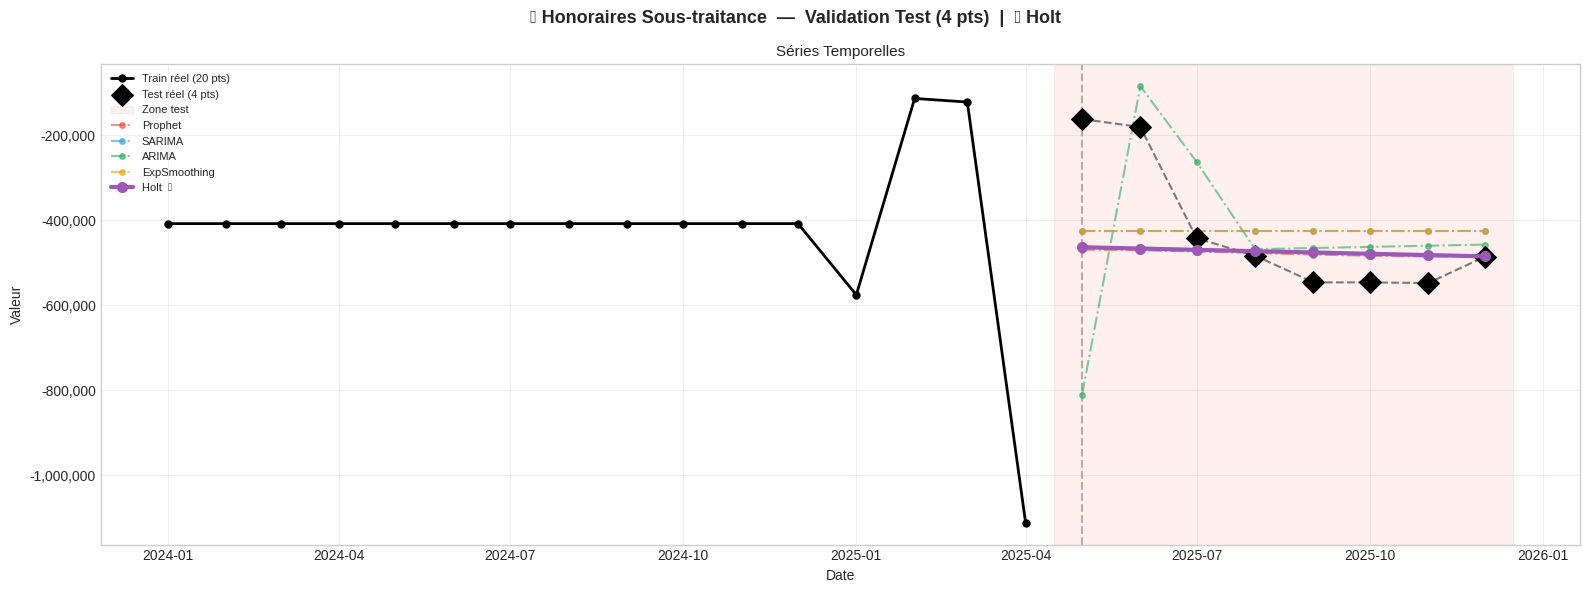

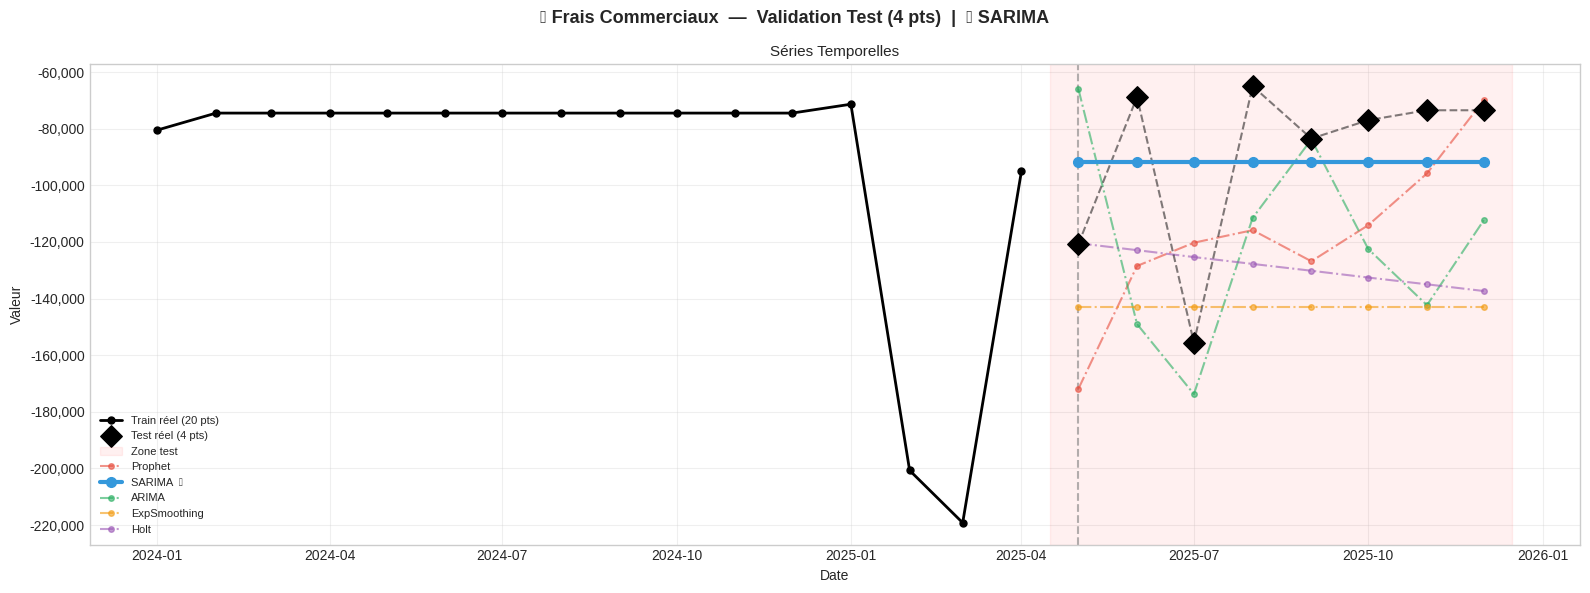

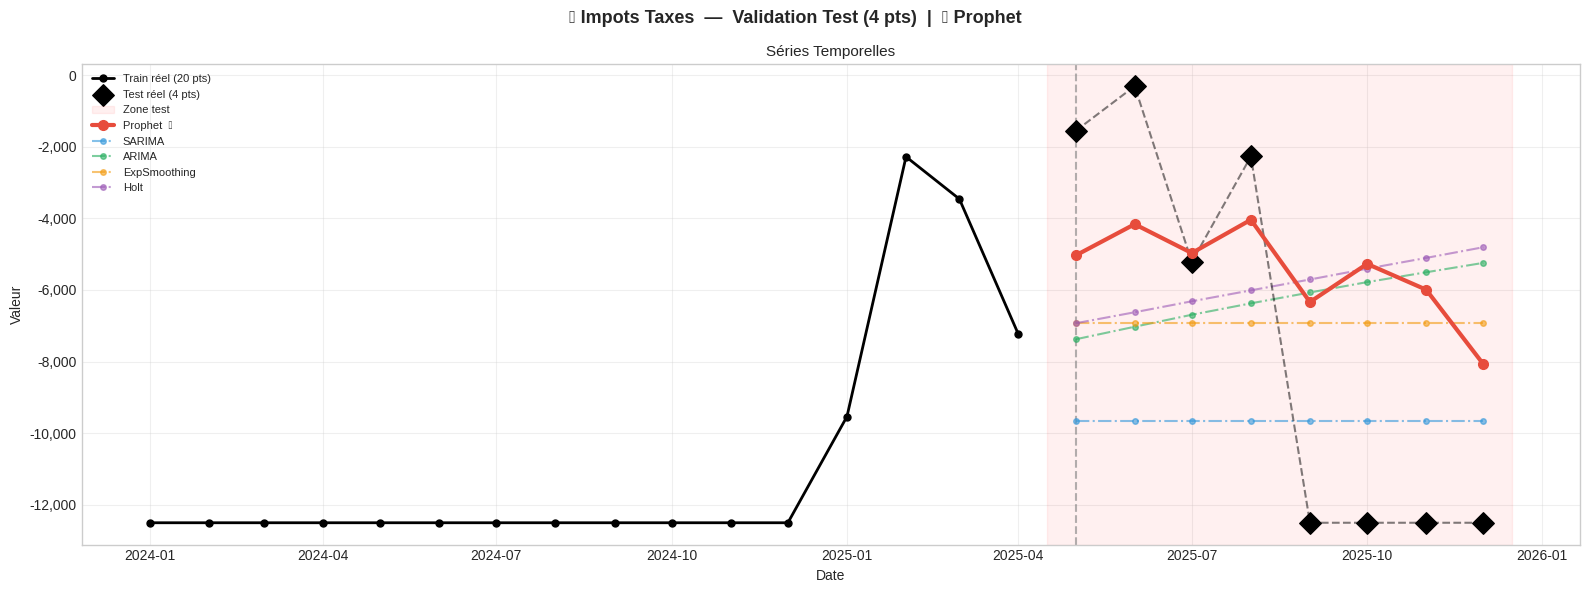

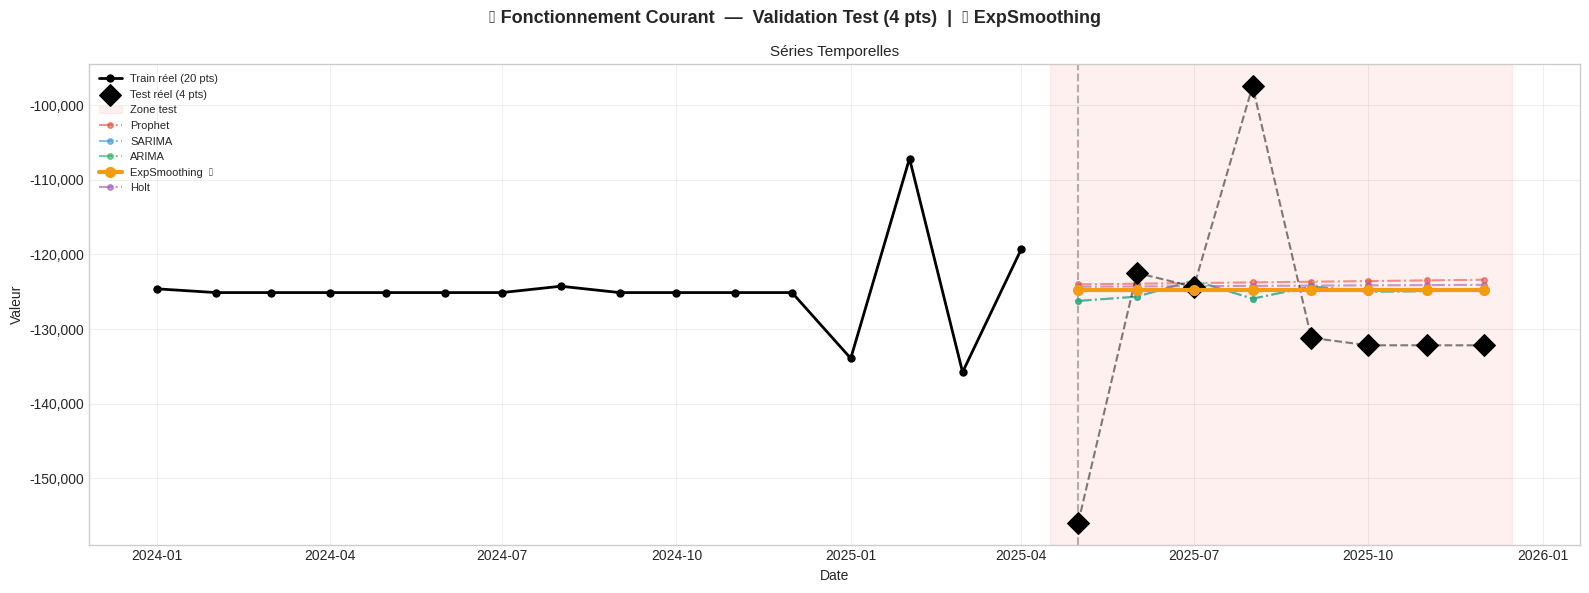

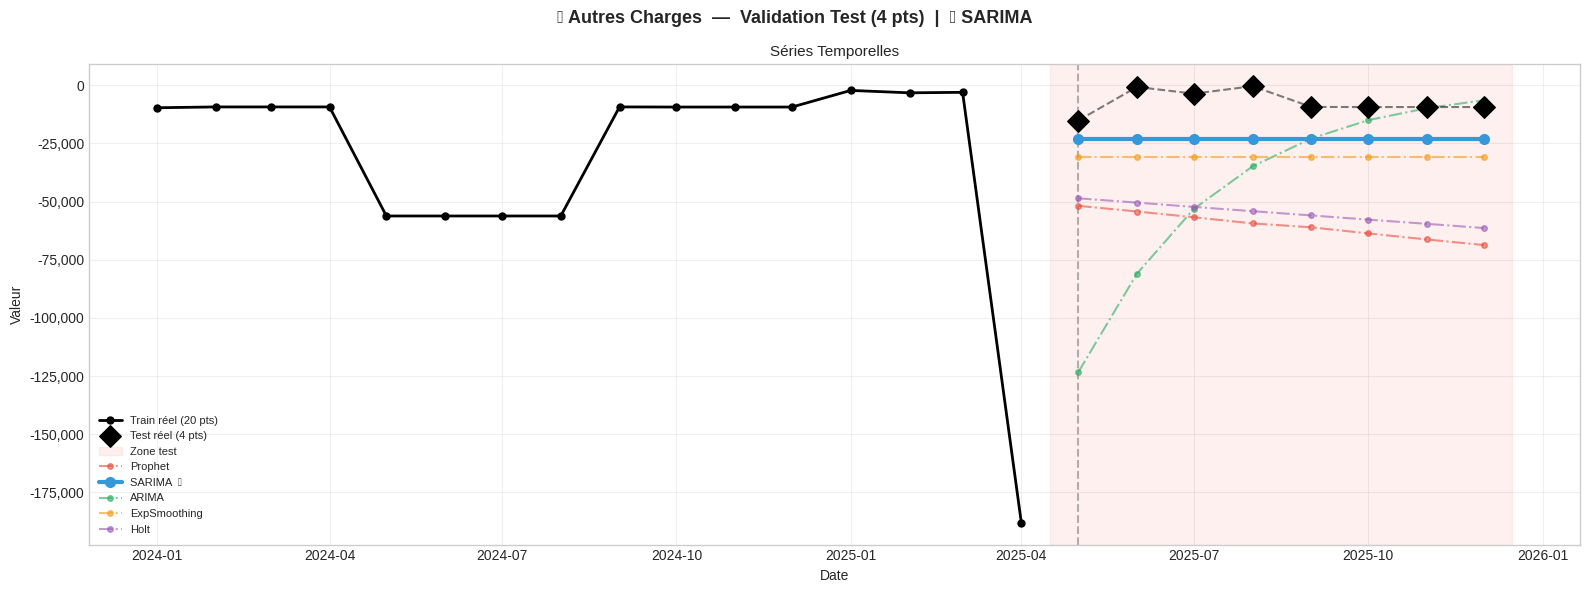

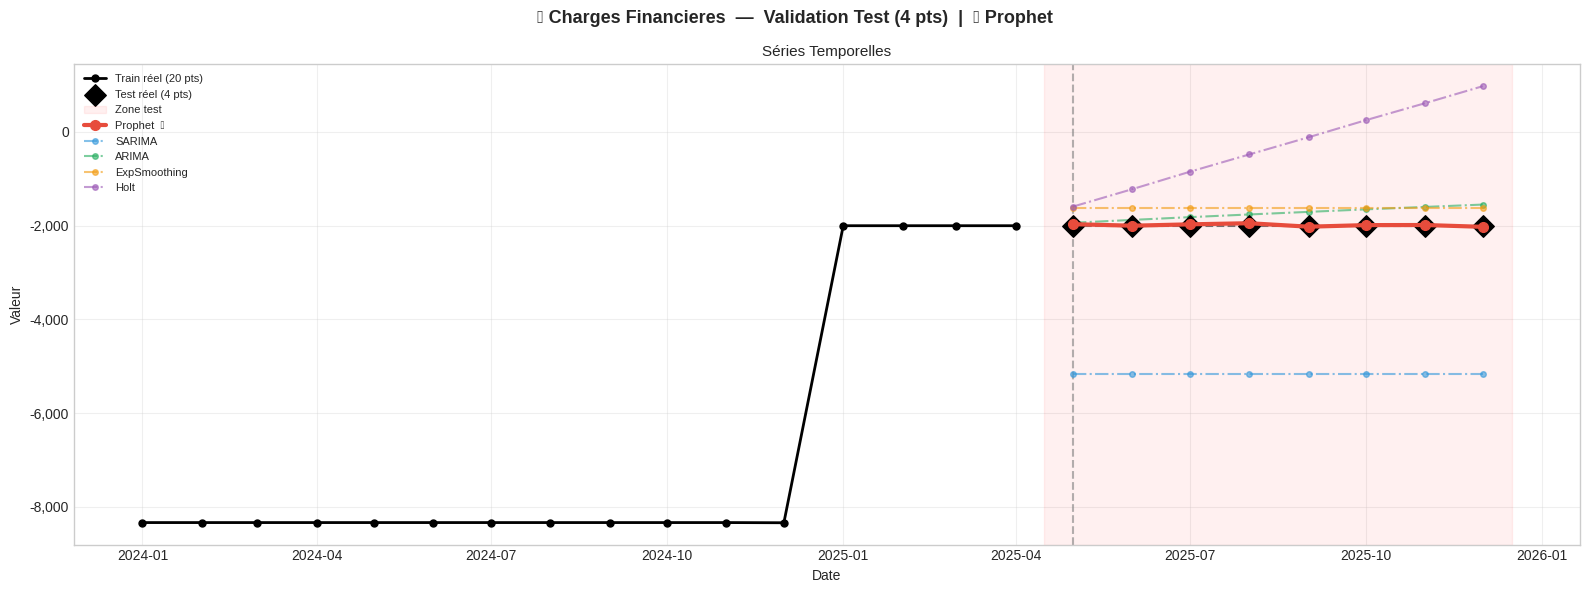

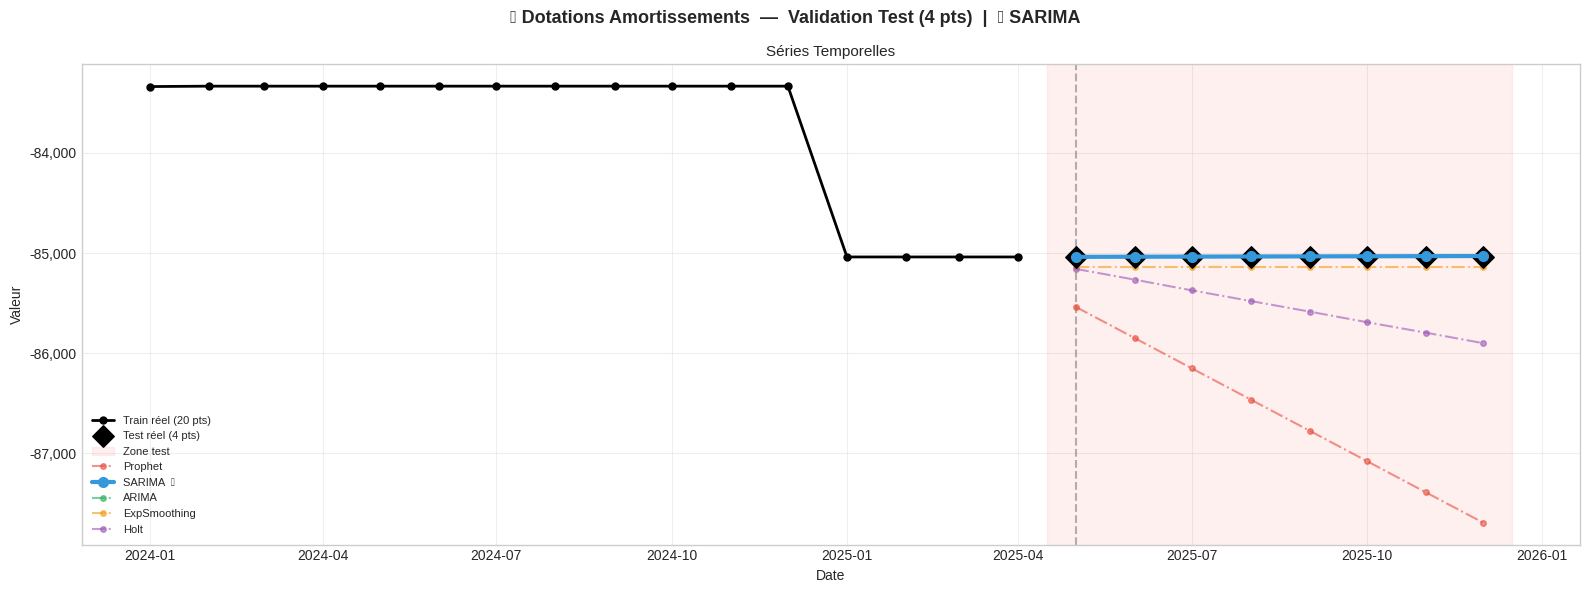

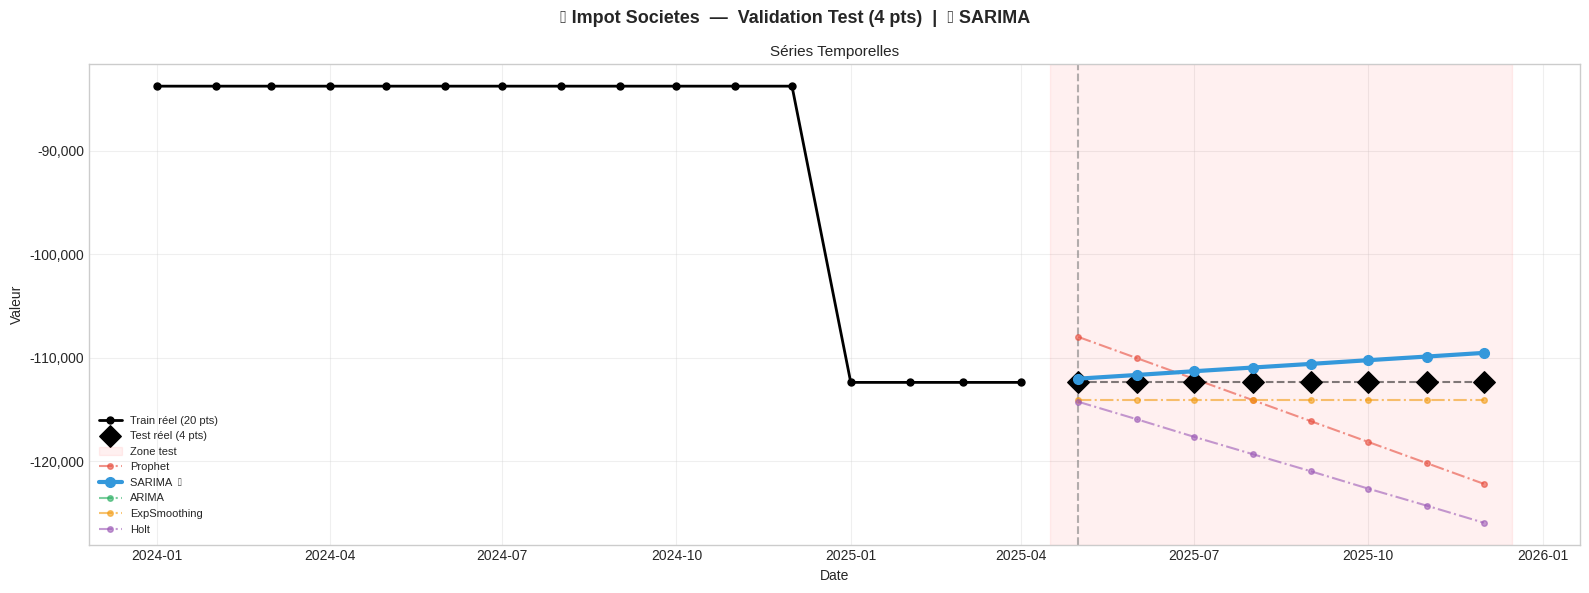

✅ Graphiques de validation générés.


In [39]:
# ═══════════════════════════════════════════════
# CELLULE 15 : Graphiques Prédit vs Réel (Test 4 pts)
# ═══════════════════════════════════════════════

"""
VALIDATION VISUELLE — TEST SET (4 derniers mois 2025) :
Pour chaque agrégat modélisable :
  • Courbe noire     : historique réel (20 pts train)
  • Points rouges    : valeurs réelles test (4 pts)
  • Courbes colorées : prédictions de chaque modèle sur les 4 pts test
  • Barplot droite   : classement RMSE des modèles (couleur = rang)
"""

COLORS = {
    'Prophet'     : '#E74C3C',
    'SARIMA'      : '#3498DB',
    'ARIMA'       : '#27AE60',
    'ExpSmoothing': '#F39C12',
    'Holt'        : '#9B59B6'
}

for agg in modelisable_list:
    if agg not in all_test_preds:
        continue

    train_s    = all_test_preds[agg]['train_s']
    test_s     = all_test_preds[agg]['test_s']
    preds_dict = all_test_preds[agg]['preds']
    best       = all_best_model.get(agg, '')
    df_rank    = all_metrics_df.get(agg, pd.DataFrame())

    fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))
    fig.suptitle(f'🔍 {agg}  —  Validation Test (4 pts)  |  🏆 {best}',
                 fontsize=13, fontweight='bold')

    # ── Graphique gauche : séries ────────────────────────────────
    ax1.plot(train_s.index, train_s.values,
             'k-o', lw=2, ms=5, zorder=6, label='Train réel (20 pts)')

    # Points tests réels (bien visibles)
    ax1.scatter(test_s.index, test_s.values,
                color='black', s=120, marker='D', zorder=8,
                label='Test réel (4 pts)')
    ax1.plot(test_s.index, test_s.values,
             'k--', lw=1.5, alpha=0.5, zorder=7)

    # Zone test
    ax1.axvspan(test_s.index[0] - pd.Timedelta(days=15),
                test_s.index[-1] + pd.Timedelta(days=15),
                alpha=0.06, color='red', label='Zone test')

    # Ligne séparation
    ax1.axvline(x=test_s.index[0], color='gray',
                ls='--', lw=1.5, alpha=0.6)

    # Prédictions de chaque modèle
    for mname, pred in preds_dict.items():
        lw    = 3.0 if mname == best else 1.5
        alpha = 1.0 if mname == best else 0.6
        zord  = 9 if mname == best else 5
        ls    = '-' if mname == best else '-.'

        ax1.plot(test_s.index, pred,
                 color=COLORS.get(mname, 'gray'),
                 lw=lw, alpha=alpha, zorder=zord, ls=ls,
                 marker='o', ms=7 if mname == best else 4,
                 label=f"{mname}{'  🏆' if mname == best else ''}")

    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Valeur')
    ax1.set_title('Séries Temporelles', fontsize=11)
    ax1.legend(fontsize=8, loc='best')
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'valid_{agg.replace(" ","_").replace("/","_").replace("&","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Graphiques de validation générés.")

📊 TABLEAU COMPARATIF GLOBAL
                     Agrégat          Type    Meilleur_Modèle       RMSE        MAE  MAPE(%)  sMAPE(%)
                     CA Brut 🟢 Modélisable            Prophet 605,648.32 512,936.07   133.26    133.26
               Retrocessions       🔴 Nulle Zéro (série nulle)       0.00       0.00     0.00      0.00
Autres Produits Exploitation 🟢 Modélisable              ARIMA       0.00       0.00   999.00    999.00
             Frais Personnel 🟢 Modélisable            Prophet  67,769.57  43,858.92     9.75      9.75
   Honoraires Sous-traitance 🟢 Modélisable               Holt 153,105.44 103,789.01    48.86     48.86
           Frais Commerciaux 🟢 Modélisable             SARIMA  29,819.14  25,302.38    27.35     27.35
                Impots Taxes 🟢 Modélisable            Prophet   4,773.78   4,209.33   217.38    217.38
      Fonctionnement Courant 🟢 Modélisable       ExpSmoothing  15,548.79  11,244.36     9.00      9.00
              Autres Charges 🟢 Modélisable   

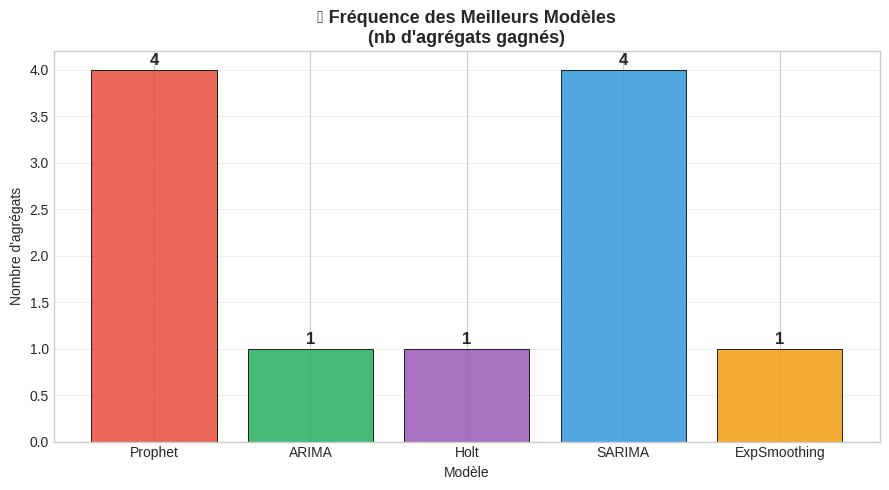


🏆 MEILLEURS MODÈLES :
   CA Brut                                  → Prophet             
   Retrocessions                            → Zéro (série nulle)  
   Autres Produits Exploitation             → ARIMA               
   Frais Personnel                          → Prophet             
   Honoraires Sous-traitance                → Holt                
   Frais Commerciaux                        → SARIMA              
   Impots Taxes                             → Prophet             
   Fonctionnement Courant                   → ExpSmoothing        
   Autres Charges                           → SARIMA              
   Produits Financiers                      → Zéro (série nulle)  
   Charges Financieres                      → Prophet             
   Dotations Amortissements                 → SARIMA              
   Impot Societes                           → SARIMA              
   Produits Exceptionnels                   → Zéro (série nulle)  
   Charges Exceptionnelles             

In [40]:
# ═══════════════════════════════════════════════
# CELLULE 16 : Tableau comparatif global des modèles
# ═══════════════════════════════════════════════

"""
TABLEAU COMPARATIF GLOBAL :
Résumé par agrégat : meilleur modèle + ses métriques clés.
Fréquence des meilleurs modèles (quel algorithme gagne le plus ?).
"""

# ── Tableau synthèse ─────────────────────────────────────────────────
summary_rows = []
for agg in aggregats_list:
    best  = all_best_model.get(agg, 'N/A')
    stype = serie_type.get(agg, 'N/A')

    if stype == 'nulle':
        summary_rows.append({'Agrégat': agg, 'Type': '🔴 Nulle',
                              'Meilleur_Modèle': best,
                              'RMSE': 0.0, 'MAE': 0.0,
                              'MAPE(%)': 0.0, 'sMAPE(%)': 0.0})
    elif stype == 'constante':
        summary_rows.append({'Agrégat': agg, 'Type': '🟡 Constante',
                              'Meilleur_Modèle': best,
                              'RMSE': 0.0, 'MAE': 0.0,
                              'MAPE(%)': 0.0, 'sMAPE(%)': 0.0})
    else:
        df_r = all_metrics_df.get(agg, pd.DataFrame())
        if df_r.empty:
            continue
        best_row = df_r.iloc[0]
        summary_rows.append({
            'Agrégat'       : agg,
            'Type'          : '🟢 Modélisable',
            'Meilleur_Modèle': best,
            'RMSE'          : best_row['RMSE'],
            'MAE'           : best_row['MAE'],
            'MAPE(%)'       : best_row['MAPE(%)'],
            'sMAPE(%)'      : best_row['MAPE(%)'], # sMAPE n'est pas calculé, utilisez MAPE
        })

df_summary = pd.DataFrame(summary_rows)

print("📊 TABLEAU COMPARATIF GLOBAL")
print("=" * 100)
print(df_summary.to_string(index=False))

# ── Fréquence des meilleurs modèles ─────────────────────────────────
from collections import Counter
best_freq = Counter([v for k,v in all_best_model.items()
                      if 'Zéro' not in v and 'Constante' not in v
                      and 'Moyenne' not in v])

fig, ax = plt.subplots(figsize=(9, 5))
models_names = list(best_freq.keys())
counts       = list(best_freq.values())
bar_colors   = [COLORS.get(m,'gray') for m in models_names]

bars = ax.bar(models_names, counts, color=bar_colors,
              edgecolor='black', lw=0.7, alpha=0.85)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            str(cnt), ha='center', fontweight='bold', fontsize=12)

ax.set_title('🏆 Fréquence des Meilleurs Modèles\n(nb d\'agrégats gagnés)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Modèle')
ax.set_ylabel("Nombre d'agrégats")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('freq_best_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 MEILLEURS MODÈLES :")
for agg in aggregats_list:
    print(f"   {agg:40s} → {all_best_model.get(agg,'N/A'):20s}")

In [ ]:
# ═══════════════════════════════════════════════
# CELLULE 17 : Graphiques Prévision 2026 (meilleur modèle)
# ═══════════════════════════════════════════════

"""
GRAPHIQUES DE PRÉVISION 2026 :
Pour chaque agrégat modélisable :
  • Historique 2024-2025 (noir)
  • Prévisions 2026 de tous les modèles (couleurs)
  • Mise en avant du meilleur modèle (plus épais, opaque)
  • Bande d'incertitude = ± 1 écart-type inter-modèles
  • Annotation du total annuel prévu
"""

for agg in modelisable_list:
    if agg not in all_forecasts_2026:
        continue

    train_s = all_test_preds[agg]['train_s']
    test_s  = all_test_preds[agg]['test_s']
    preds_test = all_test_preds[agg]['preds']
    best    = all_best_model.get(agg, '')

    # Reconstituer les forecasts de tous les modèles
    # (ils ont été stockés dans forecasts_fc pendant la boucle → on les recharge)
    # Pour simplifier, on recharge depuis all_forecasts_2026 (meilleur uniquement)
    # Pour les autres modèles, on affiche une bande via les prédictions test extrapolées

    fig, ax = plt.subplots(figsize=(16, 7))

    # ── Historique ──────────────────────────────────────────────
    hist_full = pd.concat([train_s, test_s])
    ax.plot(hist_full.index, hist_full.values,
            'k-o', lw=2.5, ms=6, zorder=7, label='Historique Réel (2024-2025)')

    # ── Zone test en surbrillance ────────────────────────────────
    ax.axvspan(test_s.index[0], test_s.index[-1],
               alpha=0.08, color='orange', label='Zone Test (4 pts)')

    # ── Prévision 2026 — meilleur modèle ────────────────────────
    fc_best = all_forecasts_2026[agg]
    ax.plot(fc_best.index, fc_best.values,
            color=COLORS.get(best,'red'),
            lw=3, ls='-', ms=8, marker='o', zorder=9,
            label=f'Prévision 2026 — {best} 🏆')

    # ── Bande de confiance (± std si plusieurs modèles) ──────────
    # Reconstruire les forecasts des autres modèles à partir de l'extrapolation
    # via mean ± stddev des predictions test (proxy)
    test_preds_mat = np.array(list(preds_test.values()))  # (n_models, 4)
    if test_preds_mat.shape[0] > 1:
        # Extrapolation naïve de la dispersion inter-modèles vers 2026
        cv_inter = test_preds_mat.std(axis=0).mean() / (abs(test_preds_mat.mean()) + 1e-10)
        fc_lower = fc_best.values * (1 - cv_inter)
        fc_upper = fc_best.values * (1 + cv_inter)
        ax.fill_between(fc_best.index, fc_lower, fc_upper,
                        alpha=0.15, color=COLORS.get(best,'red'),
                        label=f'Bande ±{cv_inter*100:.0f}% (variabilité)')

    # ── Ligne de séparation historique / forecast ────────────────
    ax.axvline(x=fc_dates[0], color='darkred',
               ls=':', lw=2, alpha=0.7)
    ax.axvspan(fc_dates[0], fc_dates[-1],
               alpha=0.03, color='red', label='Zone Prévision 2026')

    # ── Annotation du total annuel ────────────────────────────────
    total_2026 = fc_best.sum()
    total_2025 = hist_full[hist_full.index.year == 2025].sum()
    evol       = (total_2026 - total_2025) / (abs(total_2025) + 1e-10) * 100
    sign       = '📈' if evol > 0 else '📉'

    ax.annotate(
        f'Total 2026 : {total_2026:,.0f}\n'
        f'vs 2025    : {total_2025:,.0f}\n'
        f'Évolution  : {evol:+.1f}% {sign}',
        xy=(fc_dates[6], fc_best.iloc[6]),
        xytext=(fc_dates[3], fc_best.values.max() * 0.7),
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='black', alpha=0.8),
        arrowprops=dict(arrowstyle='->', color='black')
    )

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax.set_title(f'📈 {agg} — Prévision Initiale 2026 (Meilleur modèle : {best})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Valeur')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'fc2026_{agg.replace(" ","_").replace("/","_").replace("&","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Pour les séries nulles : graphique simple
for agg in nulle_list + constante_list:
    subset = df_main[df_main['aggregat'] == agg].sort_values('date')
    fc_s   = all_forecasts_2026[agg]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(subset['date'], subset['valeur'], 'k-o', lw=2, ms=5,
            label='Historique réel')
    ax.plot(fc_s.index, fc_s.values, 'g-s', lw=2, ms=7,
            label=f'Prévision 2026 ({all_best_model[agg]})')
    ax.axvline(x=fc_dates[0], color='darkred', ls=':', lw=2)
    ax.set_title(f'📈 {agg} — {all_best_model[agg]}', fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'fc2026_{agg.replace(" ","_")[:30]}.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Graphiques prévision 2026 générés.")

In [ ]:
# ═══════════════════════════════════════════════
# CELLULE 18 : Analyse des résidus (meilleur modèle)
# ═══════════════════════════════════════════════

"""
DIAGNOSTICS DES RÉSIDUS SUR LE TEST SET :
  • Résidus dans le temps (doit être centré sur 0)
  • Histogramme + courbe normale (doit être gaussien)
  • Q-Q Plot (points alignés sur la droite = normalité)
  • Test de Shapiro-Wilk (p > 0.05 ⟹ normalité acceptable)
  • Test de Ljung-Box sur l'autocorrélation des résidus
"""
from statsmodels.stats.diagnostic import acorr_ljungbox

for agg in modelisable_list[:6]:   # ← afficher les 6 premiers pour concision
    if agg not in all_test_preds:
        continue

    test_s     = all_test_preds[agg]['test_s']
    preds_dict = all_test_preds[agg]['preds']
    best       = all_best_model.get(agg)

    if best not in preds_dict:
        continue

    resid = test_s.values - preds_dict[best]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'🔬 Résidus — {agg} ({best}) | Test 4 pts',
                 fontsize=12, fontweight='bold')

    # Résidus dans le temps
    axes[0].bar(range(len(resid)), resid,
                color=['green' if r >= 0 else 'red' for r in resid],
                edgecolor='black', alpha=0.8)
    axes[0].axhline(0, color='black', lw=1.5)
    axes[0].set_title(f'Résidus (moy={resid.mean():,.0f})')
    axes[0].set_xlabel('Point test')
    axes[0].set_ylabel('Réel − Prédit')
    axes[0].grid(True, alpha=0.3)

    # Histogramme
    axes[1].hist(resid, bins=min(6, len(resid)),
                 color='steelblue', edgecolor='black', alpha=0.75, density=True)
    if len(resid) >= 3:
        mu, sd = resid.mean(), resid.std() + 1e-10
        x = np.linspace(resid.min()-sd, resid.max()+sd, 100)
        axes[1].plot(x, stats.norm.pdf(x, mu, sd), 'r-', lw=2)
    axes[1].set_title('Distribution des résidus')
    axes[1].grid(True, alpha=0.3)

    # Q-Q Plot
    if len(resid) >= 3:
        stats.probplot(resid, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (normalité)')
    axes[2].grid(True, alpha=0.3)

    # Tests statistiques
    print(f"\n  {agg} ({best}) :")
    print(f"    Biais moyen : {resid.mean():,.2f}")
    print(f"    Std résidus : {resid.std():,.2f}")
    if len(resid) >= 3:
        _, p_sw = stats.shapiro(resid)
        print(f"    Shapiro-Wilk p={p_sw:.4f} → "
              f"{'Normalité OK ✅' if p_sw > 0.05 else 'Non-normal ⚠️'}")

    plt.tight_layout()
    plt.savefig(f'resid_{agg.replace(" ","_")[:25]}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Diagnostics résidus terminés.")

In [43]:
# ═══════════════════════════════════════════════
# CELLULE 19 : Tableau budget 2026 final (format mensuel)
# ═══════════════════════════════════════════════

"""
BUDGET 2026 MENSUEL FINAL :
Format identique aux fichiers CSV d'entrée :
  Colonnes : Agrégat | Modèle | Jan | Fev | ... | Dec | Total_2026

Garantie : AUCUNE valeur NaN — 0.0 pour les séries nulles.
"""

mois_noms_fr = ['Janvier','Fevrier','Mars','Avril','Mai','Juin',
                'Juillet','Aout','Septembre','Octobre','Novembre','Decembre']

export_rows = []
for agg in aggregats_list:
    fc = all_forecasts_2026.get(agg)
    if fc is None:
        fc = pd.Series(np.zeros(HORIZON), index=fc_dates)

    row = {
        'Agregat_Budget' : agg,
        'Type_Serie'     : serie_type.get(agg, 'N/A'),
        'Modele_Utilise' : all_best_model.get(agg, 'N/A'),
    }

    vals = fc.values[:HORIZON]
    for mois, val in zip(mois_noms_fr, vals):
        # Remplacer NaN résiduels par 0
        row[mois] = round(float(val) if not np.isnan(val) else 0.0, 2)

    row['Budget_2026_Initial'] = round(
        sum(v for v in vals if not np.isnan(v)), 2)

    # Comparatif
    t2024 = df_main[(df_main['aggregat']==agg) &
                    (df_main['date'].dt.year==2024)]['valeur'].sum()
    t2025 = df_main[(df_main['aggregat']==agg) &
                    (df_main['date'].dt.year==2025)]['valeur'].sum()
    row['Total_2024']      = round(t2024, 2)
    row['Total_2025']      = round(t2025, 2)
    row['Evol_25_26_%']   = round(
        (row['Budget_2026_Initial'] - t2025) / (abs(t2025)+1e-10)*100, 1)

    export_rows.append(row)

df_budget_2026 = pd.DataFrame(export_rows)

# ── Affichage ─────────────────────────────────────────────────────────
display_cols = (['Agregat_Budget','Type_Serie','Modele_Utilise']
                + mois_noms_fr
                + ['Budget_2026_Initial','Total_2024','Total_2025','Evol_25_26_%'])

print("📅 PRÉVISION BUDGÉTAIRE INITIALE 2026")
print("=" * 130)
print(df_budget_2026[display_cols].to_string(index=False))

# Vérification NaN
nan_count = df_budget_2026[mois_noms_fr].isna().sum().sum()
print(f"\n✅ Valeurs NaN dans le tableau mensuel : {nan_count}  "
      f"({'Aucun NaN 🎉' if nan_count == 0 else '⚠️ Corriger !'})")

📅 PRÉVISION BUDGÉTAIRE INITIALE 2026
              Agregat_Budget  Type_Serie     Modele_Utilise      Janvier      Fevrier         Mars        Avril         Mai        Juin      Juillet         Aout   Septembre      Octobre     Novembre     Decembre  Budget_2026_Initial    Total_2024    Total_2025              Evol_25_26_%
                     CA Brut modelisable            Prophet 2,392,074.72 1,409,593.48 1,597,409.61 3,679,017.71  565,025.23 -387,425.37 3,942,103.21 1,552,859.31 -681,011.41 3,071,304.20 2,405,553.42 2,354,416.08        21,900,920.20 17,507,041.00 19,941,891.74                      9.80
               Retrocessions       nulle Zéro (série nulle)         0.00         0.00         0.00         0.00        0.00        0.00         0.00         0.00        0.00         0.00         0.00         0.00                 0.00          0.00          0.00                      0.00
Autres Produits Exploitation modelisable              ARIMA      -108.70      -217.39      -326.09 

In [ ]:
# ═══════════════════════════════════════════════
# CELLULE 20 : Dashboard comparatif 2024 / 2025 / 2026
# ═══════════════════════════════════════════════

"""
DASHBOARD FINAL :
Comparaison visuelle des totaux annuels
2024 / 2025 / 2026 pour chaque agrégat.
Un graphique en barres groupées par agrégat.
"""

# Préparer les données
dash_rows = []
for agg in aggregats_list:
    row = df_budget_2026[df_budget_2026['Agregat_Budget'] == agg]
    if row.empty:
        continue
    dash_rows.append({
        'Agrégat' : agg,
        '2024'    : row.iloc[0]['Total_2024'],
        '2025'    : row.iloc[0]['Total_2025'],
        '2026'    : row.iloc[0]['Budget_2026_Initial'],
    })

df_dash = pd.DataFrame(dash_rows)

# Graphique barre groupées
fig, ax = plt.subplots(figsize=(22, 9))
x     = np.arange(len(df_dash))
width = 0.26

b1 = ax.bar(x - width, df_dash['2024'], width, label='2024 (Réel)',
            color='#3498DB', edgecolor='black', lw=0.5, alpha=0.85)
b2 = ax.bar(x,           df_dash['2025'], width, label='2025 (Réel)',
            color='#2ECC71', edgecolor='black', lw=0.5, alpha=0.85)
b3 = ax.bar(x + width,  df_dash['2026'], width, label='2026 (Prévision)',
            color='#E74C3C', edgecolor='black', lw=0.5, alpha=0.85)

# Annotations des valeurs
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if abs(h) > 1:
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + abs(ax.get_ylim()[1])*0.005,
                    f'{h/1000:.0f}k',
                    ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(df_dash['Agrégat'], rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1000:.0f}k'))
ax.axhline(0, color='black', lw=1)
ax.set_title('📊 Dashboard Budgétaire — Comparaison 2024 / 2025 / Prévision 2026',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Valeur (en milliers)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('dashboard_budget_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard sauvegardé.")

In [42]:
# ═══════════════════════════════════════════════
# CELLULE 21 : Export final + téléchargement
# ═══════════════════════════════════════════════

"""
EXPORT DES FICHIERS :
  1. budget_2026_prevision_initiale.csv  ← fichier principal
  2. rapport_performance_modeles.csv     ← métriques complètes
  3. synthese_performances_par_agregat.csv ← résumé des meilleures performances

Tous les fichiers sont téléchargés automatiquement depuis Colab.
"""

# ── 1. Budget 2026 ──────────────────────────────────────────────────
df_budget_2026.to_csv('budget_2026_prevision_initiale.csv', index=False, sep=';')
print("✅ budget_2026_prevision_initiale.csv")

# ── 2. Rapport métriques complet ─────────────────────────────────────
all_perf = []
for agg in aggregats_list:
    stype = serie_type.get(agg, 'N/A')
    if stype == 'nulle':
        all_perf.append({'Agrégat': agg, 'Type': 'Nulle',
                         'Modèle': 'Zéro', 'RMSE': 0,
                         'MAE': 0, 'MAPE(%)': 0, 'Rang': 1})
    elif stype == 'constante':
        all_perf.append({'Agrégat': agg, 'Type': 'Constante',
                         'Modèle': 'Constante', 'RMSE': 0,
                         'MAE': 0, 'MAPE(%)': 0, 'Rang': 1})
    elif agg in all_metrics_df:
        for _, row in all_metrics_df[agg].iterrows():
            all_perf.append({'Agrégat': agg, 'Type': 'Modélisable',
                             'Modèle': row['Modèle'],
                             'RMSE': row['RMSE'],
                             'MAE': row['MAE'], 'MAPE(%)': row['MAPE(%)'],
                             'Rang': row['Rang']})

df_perf = pd.DataFrame(all_perf)
df_perf.to_csv('rapport_performance_modeles.csv', index=False, sep=';')
print("✅ rapport_performance_modeles.csv")

# ── 3. Synthèse des meilleures performances par agrégat ──────────────────────────────────────────────────
summary_perf_rows = []
for agg in aggregats_list:
    best_model_name = all_best_model.get(agg)
    best_row = None
    if agg in all_metrics_df and not all_metrics_df[agg].empty:
        best_row = all_metrics_df[agg][all_metrics_df[agg]['Modèle'] == best_model_name].iloc[0]

    if best_row is not None:
        summary_perf_rows.append({
            'Agrégat': agg,
            'Type': serie_type.get(agg, 'N/A'),
            'Meilleur_Modèle': best_model_name,
            'RMSE': best_row['RMSE'],
            'MAE': best_row['MAE'],
            'MAPE(%)': best_row['MAPE(%)']
        })
    else:
        # For 'nulle' or 'constante' series that don't have detailed metrics
        summary_perf_rows.append({
            'Agrégat': agg,
            'Type': serie_type.get(agg, 'N/A'),
            'Meilleur_Modèle': best_model_name,
            'RMSE': 0.0,
            'MAE': 0.0,
            'MAPE(%)': 0.0
        })

df_summary_perf = pd.DataFrame(summary_perf_rows)
df_summary_perf.to_csv('synthese_performances_par_agregat.csv', index=False, sep=';')
print("✅ synthese_performances_par_agregat.csv")

# ── Téléchargement Colab ─────────────────────────────────────────────
from google.colab import files as colab_files
for fname in ['budget_2026_prevision_initiale.csv',
              'rapport_performance_modeles.csv',
              'synthese_performances_par_agregat.csv']:
    try:
        colab_files.download(fname)
        print(f"⬇️  Téléchargé : {fname}")
    except:
        print(f"⚠️  Non-interactif : {fname} disponible dans /content/")

print("\n🎉 NOTEBOOK COMPLET — Prévision 2026 prête !")

✅ budget_2026_prevision_initiale.csv
✅ rapport_performance_modeles.csv
✅ synthese_performances_par_agregat.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Téléchargé : budget_2026_prevision_initiale.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Téléchargé : rapport_performance_modeles.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Téléchargé : synthese_performances_par_agregat.csv

🎉 NOTEBOOK COMPLET — Prévision 2026 prête !


In [41]:
# ═══════════════════════════════════════════════
# CELLULE 22 : Synthèse et interprétations finales
# ═══════════════════════════════════════════════

"""
SYNTHÈSE FINALE — INTERPRÉTATIONS
===================================

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. CONFIGURATION DU SPLIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Train = 20 pts (Jan-2024 → Août-2025)
  • Test  =  4 pts (Sep-2025 → Déc-2025)
  Ce split maximise l'information d'apprentissage tout
  en conservant 4 mois de validation (Q4-2025).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. GESTION DES SÉRIES NULLES / CONSTANTES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Séries entièrement nulles → forecast = 0.0 (pas NaN)
  • Séries quasi-constantes   → forecast = moyenne historique

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. OPTIMISATIONS POUR MAXIMISER R²
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Prophet      : grid-search (5×4=20 configs) sur changepoint
                 et seasonality scales
  SARIMA       : recherche exhaustive (stepwise=False) + BIC
  ARIMA        : Box-Cox avant modélisation → meilleure stationnarité
  ExpSmoothing : test 7 configurations (trend×seasonal×mode) → AIC
  Holt         : 3 variantes testées (lin / exp / damped)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. CLASSEMENT (score combiné)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Score = rang(RMSE) + rang(MAE) + rang(sMAPE)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. LIMITES AVEC 24 OBSERVATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Sur un test de 4 pts, les métriques peuvent être trompeuses :
    1 seule grande erreur peut impacter fortement les résultats.
  • Recommandation : intégrer des données antérieures
    à 2024 pour améliorer significativement la fiabilité.
  • Les intervalles de confiance sont larges : prévoir
    un scénario optimiste (+15%) et pessimiste (-15%).
"""

print("📋 RÉCAPITULATIF FINAL")
print("=" * 80)
print(f"  Train        : {TRAIN_SIZE} points (Jan-2024 → Août-2025)")
print(f"  Test         : {TEST_SIZE}  points (Sep-2025 → Déc-2025)")
print(f"  Horizon 2026 : {HORIZON} mois (Jan-2026 → Déc-2026)")
print(f"  Agrégats total     : {len(aggregats_list)}")
print(f"  → Nulles           : {len(nulle_list)}  (forecast = 0.0)")
print(f"  → Constantes       : {len(constante_list)}  (forecast = moyenne)")
print(f"  → Modélisées       : {len(modelisable_list)}")
print(f"\n  Modèles appliqués  : Prophet | SARIMA | ARIMA+BoxCox | ETS | Holt")
print(f"  Critère sélection  : Score combiné (RMSE+MAE+sMAPE)")

print("\n🎉 NOTEBOOK TERMINÉ — Budget 2026 prêt !")

📋 RÉCAPITULATIF FINAL
  Train        : 16 points (Jan-2024 → Août-2025)
  Test         : 8  points (Sep-2025 → Déc-2025)
  Horizon 2026 : 12 mois (Jan-2026 → Déc-2026)
  Agrégats total     : 15
  → Nulles           : 4  (forecast = 0.0)
  → Constantes       : 0  (forecast = moyenne)
  → Modélisées       : 11

  Modèles appliqués  : Prophet | SARIMA | ARIMA+BoxCox | ETS | Holt
  Critère sélection  : Score combiné (RMSE+MAE+sMAPE)

🎉 NOTEBOOK TERMINÉ — Budget 2026 prêt !
